## Simulation setup

### Hardware

In [128]:
# =============================================================================
# SPECTROGRAPH CONFIGURATION — edit this cell, then Run All
# =============================================================================
from types import SimpleNamespace as NS
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import poppy
import poppy.fresnel as fresnel

CONFIG = NS(
    optics=NS(
        slit_width_um=20.0,
        slit_length_mm=3.0,
        collimator_focal_length_mm=75.0,
        collimator_distance_mm=75.0,
        focusing_focal_length_mm=30.0,
        lens_separation_mm=30.0,
        detector_distance_mm=30.0,
        pupil_diameter_mm=25.4,
        poppy_npix=512,
    ),
    grating=NS(
        lines_per_mm=300.0,
        diffraction_order=1,
        incidence_angle_deg=0.0,
    ),
    detector=NS(
        width_px=1440,
        height_px=1080,
        pixel_size_um=3.45,
        psf_fov_pixels=512,
        bayer_pattern="RGGB",
    ),
    spectrum=NS(
        min_wavelength_nm=400.0,
        max_wavelength_nm=700.0,
        samples=601,
        center_wavelength_nm=551.7,
    ),
    rgb_source=(
        NS(name="blue",  center_nm=450.0, fwhm_nm=10.0, amplitude=1.0),
        NS(name="green", center_nm=530.0, fwhm_nm=10.0, amplitude=1.0),
        NS(name="red",   center_nm=620.0, fwhm_nm=10.0, amplitude=1.0),
    ),
    calibration=NS(
        line_wavelengths_nm=np.array([435.83, 546.07, 615.22, 696.54]),
        polynomial_degree=2,
        smoothing_sigma_px=3.0,
        peak_min_distance_px=40,
        peak_height_fraction=0.01,
        peak_prominence_fraction=0.02,
    ),
    analysis=NS(
        resolution_test_wavelength_nm=550.0,
        resolution_curve_points=21,
        point_source_radius_um=5.0,
    ),
    qe=NS(
        wavelengths_nm=np.array([400, 425, 450, 475, 500, 525, 550, 575, 600, 625, 650, 675, 700]),
        blue=np.array([0.28, 0.42, 0.53, 0.48, 0.25, 0.12, 0.05, 0.02, 0.01, 0.01, 0.02, 0.03, 0.03]),
        green=np.array([0.05, 0.03, 0.05, 0.30, 0.60, 0.65, 0.62, 0.50, 0.30, 0.15, 0.11, 0.10, 0.18]),
        red=np.array([0.06, 0.04, 0.02, 0.02, 0.03, 0.04, 0.03, 0.25, 0.62, 0.58, 0.55, 0.46, 0.42]),
    ),
)


def validate_config(cfg=CONFIG):
    """Fail early when a hardware configuration is physically inconsistent."""
    if cfg.grating.lines_per_mm <= 0:
        raise ValueError("grating.lines_per_mm must be positive")
    if cfg.grating.diffraction_order < 1:
        raise ValueError("grating.diffraction_order must be at least 1")
    if cfg.detector.width_px <= 0 or cfg.detector.height_px <= 0:
        raise ValueError("detector dimensions must be positive")
    if cfg.detector.pixel_size_um <= 0:
        raise ValueError("detector.pixel_size_um must be positive")
    if cfg.spectrum.min_wavelength_nm >= cfg.spectrum.max_wavelength_nm:
        raise ValueError("spectrum minimum must be below its maximum")

    spacing_nm = 1e6 / cfg.grating.lines_per_mm
    alpha = np.deg2rad(cfg.grating.incidence_angle_deg)
    edge = cfg.grating.diffraction_order * cfg.spectrum.max_wavelength_nm / spacing_nm - np.sin(alpha)
    if abs(edge) > 1:
        raise ValueError("The selected grating/order cannot diffract the full wavelength range")


validate_config()

# Derived values used throughout the notebook. Do not edit this section.
sensor_height = CONFIG.detector.height_px
sensor_width = CONFIG.detector.width_px
pixel_size = CONFIG.detector.pixel_size_um * u.micron
f_focus = CONFIG.optics.focusing_focal_length_mm * u.mm
f_collimator = CONFIG.optics.collimator_focal_length_mm * u.mm
w_slit = CONFIG.optics.slit_width_um * u.micron
d_spacing = (1e6 / CONFIG.grating.lines_per_mm) * u.nm
center_wl = CONFIG.spectrum.center_wavelength_nm * u.nm
wavelengths = np.linspace(
    CONFIG.spectrum.min_wavelength_nm,
    CONFIG.spectrum.max_wavelength_nm,
    CONFIG.spectrum.samples,
) * u.nm
qe_wavelengths = CONFIG.qe.wavelengths_nm
qe_blue_curve = CONFIG.qe.blue
qe_green_curve = CONFIG.qe.green
qe_red_curve = CONFIG.qe.red


def diffraction_angle(wavelength):
    """Return the grating diffraction angle for a wavelength Quantity."""
    alpha = np.deg2rad(CONFIG.grating.incidence_angle_deg)
    argument = (
        CONFIG.grating.diffraction_order * (wavelength / d_spacing).decompose().value
        - np.sin(alpha)
    )
    return np.arcsin(argument)


def create_spectrograph_system(wavelength_nm):
    """Build the POPPY model entirely from CONFIG."""
    o = CONFIG.optics
    osys = fresnel.FresnelOpticalSystem(
        name=f"Spectrograph at {wavelength_nm} nm",
        pupil_diameter=o.pupil_diameter_mm * u.mm,
        npix=o.poppy_npix,
    )
    osys.add_optic(poppy.RectangleAperture(
        width=o.slit_width_um * u.micron,
        height=o.slit_length_mm * u.mm,
        name="Long Slit",
    ))
    osys.add_optic(
        poppy.QuadraticLens(
            f_lens=o.collimator_focal_length_mm * u.mm,
            name="Collimator Lens",
        ),
        distance=o.collimator_distance_mm * u.mm,
    )
    osys.add_optic(
        poppy.QuadraticLens(
            f_lens=o.focusing_focal_length_mm * u.mm,
            name="Focusing Lens",
        ),
        distance=o.lens_separation_mm * u.mm,
    )
    osys.add_detector(
        pixelscale=CONFIG.detector.pixel_size_um * u.micron / u.pixel,
        fov_pixels=CONFIG.detector.psf_fov_pixels,
        distance=o.detector_distance_mm * u.mm,
    )
    return osys


def rgb_gaussian_source(wl_nm):
    """Return the synthetic RGB source intensity configured above."""
    intensity = np.zeros_like(np.asarray(wl_nm, dtype=float))
    for component in CONFIG.rgb_source:
        sigma_nm = component.fwhm_nm / (2 * np.sqrt(2 * np.log(2)))
        intensity += component.amplitude * np.exp(
            -0.5 * ((wl_nm - component.center_nm) / sigma_nm) ** 2
        )
    return intensity


print(
    f"Configured: {CONFIG.grating.lines_per_mm:g} lines/mm, "
    f"{CONFIG.optics.slit_width_um:g} µm slit, "
    f"f_coll={CONFIG.optics.collimator_focal_length_mm:g} mm, "
    f"f_focus={CONFIG.optics.focusing_focal_length_mm:g} mm, "
    f"{sensor_width}×{sensor_height} detector"
)

Configured: 300 lines/mm, 20 µm slit, f_coll=75 mm, f_focus=30 mm, 1440×1080 detector


### Simulating Bayer matrix

In [129]:
# Detector-sized Bayer masks (dimensions come from CONFIG).
if CONFIG.detector.bayer_pattern != "RGGB":
    raise NotImplementedError("Only the RGGB Bayer pattern is currently implemented")

final_sensor_image = np.zeros((sensor_height, sensor_width))
red_mask = np.zeros((sensor_height, sensor_width))
green_mask = np.zeros((sensor_height, sensor_width))
blue_mask = np.zeros((sensor_height, sensor_width))

red_mask[0::2, 0::2] = 1.0
green_mask[0::2, 1::2] = 1.0
green_mask[1::2, 0::2] = 1.0
blue_mask[1::2, 1::2] = 1.0


### Simulating the grating diffraction

In [130]:

# # 1. Fix dimensions: (Height/Vertical, Width/Horizontal)
# sensor_height = 1080
# sensor_width = 1440
# final_spectrum_image = np.zeros((sensor_height, sensor_width)) 

# wavelengths = np.linspace(400, 700, 300) * u.nm # wavelengths from 400 nm to 700 nm, 300 steps
# d_spacing = 1666.67 * u.nm 
# f_focus = 30 * u.mm 
# pixel_size = 3.45 * u.micron

# # 2. Define our camera center point (550 nm is green light, dead center of human vision)
# center_wl = 550 * u.nm
# center_theta = np.arcsin(center_wl / d_spacing)
# center_x = f_focus * np.tan(center_theta)
# center_pixel_offset = int(center_x / pixel_size)

# # Reference wavelength anchor points (nm) covering your 400-700nm range
# qe_wavelengths = np.array([400, 425, 450, 475, 500, 525, 550, 575, 600, 625, 650, 675, 700])

# # Quantum Efficiency values (as fractions between 0.0 and 1.0) approximated from the Thorlabs chart
# qe_blue_curve  = np.array([0.28, 0.42, 0.53, 0.48, 0.25, 0.12, 0.05, 0.02, 0.01, 0.01, 0.02, 0.03, 0.03])
# qe_green_curve = np.array([0.05, 0.03, 0.05, 0.30, 0.60, 0.65, 0.62, 0.50, 0.30, 0.15, 0.11, 0.10, 0.18])
# qe_red_curve   = np.array([0.06, 0.04, 0.02, 0.02, 0.03, 0.04, 0.03, 0.25, 0.62, 0.58, 0.55, 0.46, 0.42])

# for wl in wavelengths:
#     # Compute the monochromatic wavefront profile at the detector
#     psf = osys.calc_psf(wavelength=wl)
#     mono_image = psf[0].data 
    
#     # Grating math: physical displacement on the sensor matrix
#     theta = np.arcsin(wl / d_spacing) 
#     x_position = f_focus * np.tan(theta) 
#     absolute_pixel = int(x_position / pixel_size) 
    
#     # Shift relative to the middle column of our sensor (pixel 720)
#     pixel_shift = absolute_pixel - center_pixel_offset + (sensor_width // 2)
    
#     # Map to the sensor 
#     h_h, w_h = mono_image.shape
#     y_offset = (sensor_height - h_h) // 2
    
#     # Only map the light if it physically lands within the sensor boundaries
#     if 0 <= pixel_shift < (sensor_width - w_h):
        
#         wl_nm = wl.to(u.nm).value
        
#         # CONTINUOUS QE: Interpolate the exact efficiency for this specific wavelength
#         qe_b = np.interp(wl_nm, qe_wavelengths, qe_blue_curve)
#         qe_g = np.interp(wl_nm, qe_wavelengths, qe_green_curve)
#         qe_r = np.interp(wl_nm, qe_wavelengths, qe_red_curve)
        
#         # Slice the individual color masks for this sub-region
#         b_slice = blue_mask[y_offset:y_offset+h_h, pixel_shift:pixel_shift+w_h]
#         g_slice = green_mask[y_offset:y_offset+h_h, pixel_shift:pixel_shift+w_h]
#         r_slice = red_mask[y_offset:y_offset+h_h, pixel_shift:pixel_shift+w_h]
        
#         # Combine them simultaneously! 
#         # A single monochromatic line will now realistically illuminate multiple pixel types based on the curves.
#         combined_response = (qe_b * b_slice) + (qe_g * g_slice) + (qe_r * r_slice)
        
#         # Apply the hardware response to the final image matrix
#         final_spectrum_image[y_offset:y_offset+h_h, pixel_shift:pixel_shift+w_h] += (mono_image * combined_response)
# # Display simulated matrix 
# plt.figure(figsize=(12, 6))
# plt.imshow(np.sqrt(final_spectrum_image), cmap='inferno', extent=[0, sensor_width, sensor_height, 0]) 
# plt.title("Simulation: 2D Long-Slit Spectrum (400-700nm on 1440x1080 Sensor)")
# plt.xlabel("Spectral axis (Column Pixel)")
# plt.ylabel("Spatial position (Row Pixel)")
# plt.colorbar(label='Intensity')
# plt.show()

#### RGB light source

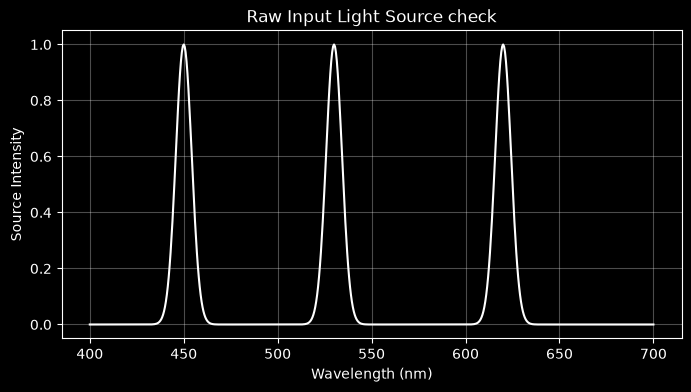

center_wl: 551.7 nm
center_pixel_offset: 1459.3445


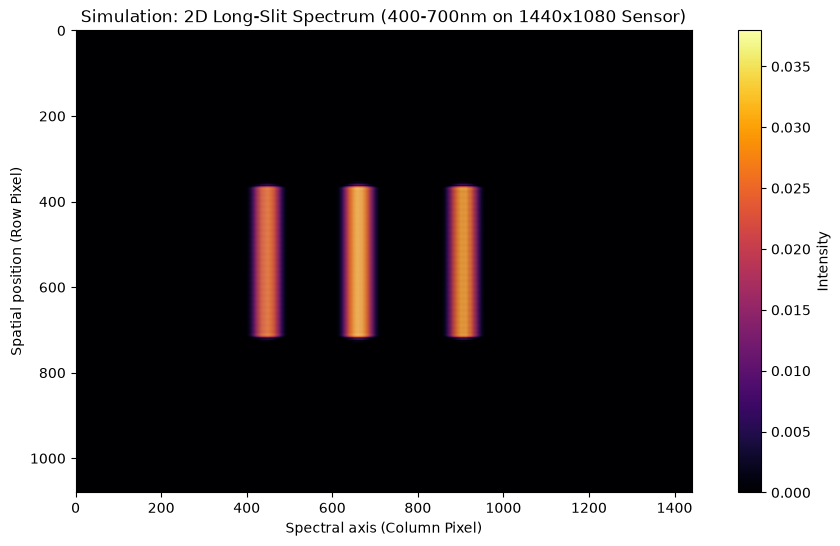

In [131]:
# All source, optical, detector, grating, wavelength, and QE values come from CONFIG.

# Test the function directly
test_wavelengths = wavelengths.to_value(u.nm)
test_intensities = [rgb_gaussian_source(wl) for wl in test_wavelengths]

plt.style.use('dark_background')
plt.figure(figsize=(8, 4))
plt.plot(test_wavelengths, test_intensities, color='white')
plt.title("Raw Input Light Source check")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Source Intensity")
plt.grid(alpha=0.3)
plt.show()
plt.style.use('default')

# Create a fresh blank sensor matrix for the Gaussian test
gaussian_test_image = np.zeros((sensor_height, sensor_width))

center_theta = diffraction_angle(center_wl)
center_x = f_focus * np.tan(center_theta)
center_pixel_offset = (center_x / pixel_size).decompose().value  # float, no int()

#check
print(f"center_wl: {center_wl}")
print(f"center_pixel_offset: {center_pixel_offset:.4f}")

# Loop through continuous wavelengths (e.g., 400 to 700 nm)
for wl in wavelengths:
    osys = create_spectrograph_system(wl.to_value(u.nm))
    psf = osys.calc_psf(wavelength=wl)
    mono_image = psf[0].data 
    
    # Inside the loop — keep float until the final round()
    theta = diffraction_angle(wl)
    x_position = f_focus * np.tan(theta)
    absolute_pixel = (x_position / pixel_size).decompose().value  # float, no int()
    pixel_shift = int(round(absolute_pixel - center_pixel_offset + (sensor_width // 2)))
    
    h_h, w_h = mono_image.shape
    y_offset = (sensor_height - h_h) // 2
    
    # Center the PSF stamp on pixel_shift, not left-align it
    stamp_left = pixel_shift - w_h // 2
    x0 = max(stamp_left, 0)
    x1 = min(stamp_left + w_h, sensor_width)

    if x1 > x0 and y_offset >= 0:
        src_x0 = x0 - stamp_left
        src_x1 = src_x0 + (x1 - x0)

        wl_nm = wl.to(u.nm).value

        source_intensity = rgb_gaussian_source(wl_nm)

        qe_b = np.interp(wl_nm, qe_wavelengths, qe_blue_curve)
        qe_g = np.interp(wl_nm, qe_wavelengths, qe_green_curve)
        qe_r = np.interp(wl_nm, qe_wavelengths, qe_red_curve)

        b_slice = blue_mask[y_offset:y_offset+h_h, x0:x1]
        g_slice = green_mask[y_offset:y_offset+h_h, x0:x1]
        r_slice = red_mask[y_offset:y_offset+h_h, x0:x1]

        combined_response = (qe_b * b_slice) + (qe_g * g_slice) + (qe_r * r_slice)

        gaussian_test_image[y_offset:y_offset+h_h, x0:x1] += (
            mono_image[:, src_x0:src_x1] * combined_response * source_intensity
        )
        
plt.figure(figsize=(12, 6))
plt.imshow(np.sqrt(gaussian_test_image), cmap='inferno', extent=[0, sensor_width, sensor_height, 0]) 
plt.title("Simulation: 2D Long-Slit Spectrum (400-700nm on 1440x1080 Sensor)")
plt.xlabel("Spectral axis (Column Pixel)")
plt.ylabel("Spatial position (Row Pixel)")
plt.colorbar(label='Intensity')
# Test 1: Logarithmic scale to reveal faint vertical wings
plt.imshow(
    np.log10(gaussian_test_image + 1e-6), 
    cmap='inferno', 
    extent=[0, sensor_width, sensor_height, 0]
)


### Measuring true resolving power

This section uses a scale-separated hybrid model. POPPY propagates the full 25.4 mm focusing-lens pupil on a fixed physical detector grid; the entrance slit is projected geometrically and convolved in the detector plane, so its 20 µm physical width is never sampled on the coarse pupil grid. A finite-grating sinc² kernel and exact fractional detector-pixel integration complete the simulated line-spread function. The theoretical RSS curve intentionally excludes lens diffraction, as requested, while the simulated curve naturally retains the POPPY optical PSF.

In [ ]:
# =============================================================================
# CORRECTED HYBRID POPPY RESOLUTION MODEL
# POPPY pupil PSF -> projected slit -> sinc² grating -> pixel integration
# =============================================================================
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

RESOLUTION_MODEL = NS(
    fine_scale_um=0.20,
    physical_fov_um=128.0,
)

RESOLUTION_POPPY_CACHE = {}


def resolution_fractional_tophat(width_samples):
    '''Normalized top-hat sampled by exact fractional cell overlap.'''
    if width_samples <= 0:
        raise ValueError("Top-hat width must be positive")
    half_width = width_samples / 2.0
    radius = int(np.ceil(half_width + 0.5))
    centers = np.arange(-radius, radius + 1, dtype=float)
    overlap = np.maximum(
        0.0,
        np.minimum(centers + 0.5, half_width)
        - np.maximum(centers - 0.5, -half_width),
    )
    return overlap / overlap.sum()


def resolution_sinc_squared(fwhm_samples):
    '''Normalized sinc² kernel with the requested full width at half maximum.'''
    if fwhm_samples <= 0:
        raise ValueError("sinc-squared FWHM must be positive")
    scale = fwhm_samples / 0.885893
    radius = max(2, int(np.ceil(12.0 * scale)))
    coordinates = np.arange(-radius, radius + 1, dtype=float)
    kernel = np.sinc(coordinates / scale) ** 2
    return kernel / kernel.sum()


def resolution_fwhm(profile, coordinates=None):
    '''Measure nearest interpolated half-maximum crossings.'''
    profile = np.asarray(profile, dtype=float)
    if coordinates is None:
        coordinates = np.arange(profile.size, dtype=float)
    coordinates = np.asarray(coordinates, dtype=float)
    if profile.shape != coordinates.shape:
        raise ValueError("profile and coordinates must have the same shape")
    if profile.size < 3 or np.max(profile) <= 0:
        return np.nan, np.nan, np.nan

    peak = int(np.argmax(profile))
    half_maximum = profile[peak] / 2.0
    left_candidates = np.where(profile[:peak] < half_maximum)[0]
    right_candidates = np.where(profile[peak + 1:] < half_maximum)[0]
    if left_candidates.size == 0 or right_candidates.size == 0:
        return np.nan, np.nan, np.nan

    left0 = left_candidates[-1]
    left1 = left0 + 1
    right0 = peak + 1 + right_candidates[0]
    right1 = right0 - 1
    left_crossing = np.interp(
        half_maximum,
        [profile[left0], profile[left1]],
        [coordinates[left0], coordinates[left1]],
    )
    right_crossing = np.interp(
        half_maximum,
        [profile[right0], profile[right1]],
        [coordinates[right0], coordinates[right1]],
    )
    return (
        abs(right_crossing - left_crossing),
        left_crossing,
        right_crossing,
    )


def resolution_optical_lsf(wavelength_nm):
    '''Calculate and cache a fixed-physical-grid full-pupil POPPY lens LSF.'''
    wavelength_nm = float(wavelength_nm)
    if wavelength_nm in RESOLUTION_POPPY_CACHE:
        cached = RESOLUTION_POPPY_CACHE[wavelength_nm]
        return cached["lsf"].copy(), cached["optical_fwhm_um"]

    fine_scale_um = RESOLUTION_MODEL.fine_scale_um
    fov_pixels = int(round(
        RESOLUTION_MODEL.physical_fov_um / fine_scale_um
    ))
    if fov_pixels % 2:
        fov_pixels += 1

    optical_system = fresnel.FresnelOpticalSystem(
        name=f"Full-pupil resolution PSF at {wavelength_nm:g} nm",
        pupil_diameter=CONFIG.optics.pupil_diameter_mm * u.mm,
        npix=CONFIG.optics.poppy_npix,
    )
    optical_system.add_optic(poppy.CircularAperture(
        radius=CONFIG.optics.pupil_diameter_mm * u.mm / 2.0,
        name="Full Illuminated Pupil",
    ))
    optical_system.add_optic(poppy.QuadraticLens(
        f_lens=CONFIG.optics.focusing_focal_length_mm * u.mm,
        name="Focusing Lens",
    ))
    optical_system.add_detector(
        pixelscale=fine_scale_um * u.micron / u.pixel,
        fov_pixels=fov_pixels,
        distance=CONFIG.optics.detector_distance_mm * u.mm,
    )
    optical_psf = optical_system.calc_psf(
        wavelength=wavelength_nm * u.nm
    )[0].data
    optical_lsf = np.sum(optical_psf, axis=0)
    optical_lsf /= optical_lsf.sum()
    fine_coordinates_um = (
        np.arange(optical_lsf.size) - (optical_lsf.size - 1) / 2.0
    ) * fine_scale_um
    optical_fwhm_um, _, _ = resolution_fwhm(
        optical_lsf, fine_coordinates_um
    )
    RESOLUTION_POPPY_CACHE[wavelength_nm] = {
        "lsf": optical_lsf.copy(),
        "optical_fwhm_um": optical_fwhm_um,
    }
    return optical_lsf, optical_fwhm_um


def resolution_integrate_pixels(fine_lsf, fine_scale_um, pixel_size_um):
    '''Integrate a local fine-grid LSF into arbitrary physical pixel boundaries.'''
    fine_lsf = np.asarray(fine_lsf, dtype=float)
    fine_lsf = fine_lsf / fine_lsf.sum()
    fine_edges_um = (
        np.arange(fine_lsf.size + 1) - fine_lsf.size / 2.0
    ) * fine_scale_um
    cumulative_counts = np.concatenate(([0.0], np.cumsum(fine_lsf)))
    available_half_width_um = min(
        abs(fine_edges_um[0]), abs(fine_edges_um[-1])
    )
    half_pixel_count = int(np.floor(
        available_half_width_um / pixel_size_um - 0.5
    ))
    if half_pixel_count < 2:
        raise RuntimeError("Resolution-model field is too small for the detector")

    detector_offsets_px = np.arange(
        -half_pixel_count, half_pixel_count + 1, dtype=float
    )
    detector_edges_um = (
        np.arange(-half_pixel_count, half_pixel_count + 2, dtype=float)
        - 0.5
    ) * pixel_size_um
    counts_at_edges = np.interp(
        detector_edges_um, fine_edges_um, cumulative_counts
    )
    detector_profile = np.diff(counts_at_edges)
    detector_profile /= detector_profile.sum()
    return detector_offsets_px, detector_profile


def simulate_hybrid_resolution_line(wavelength_nm, cfg=CONFIG):
    '''Simulate one line without placing a micrometre slit on the pupil grid.'''
    wavelength_nm = float(wavelength_nm)
    spacing_nm = 1e6 / cfg.grating.lines_per_mm
    order = cfg.grating.diffraction_order
    alpha = np.deg2rad(cfg.grating.incidence_angle_deg)
    grating_argument = (
        order * wavelength_nm / spacing_nm - np.sin(alpha)
    )
    if abs(grating_argument) > 1.0:
        raise ValueError("The configured grating cannot diffract this wavelength")
    beta = np.arcsin(grating_argument)

    # 1. POPPY models only the well-sampled full-pupil focusing-lens PSF.
    optical_lsf, optical_fwhm_um = resolution_optical_lsf(wavelength_nm)
    fine_scale_um = RESOLUTION_MODEL.fine_scale_um

    # 2. Project the two physical entrance-slit edges through the grating exactly.
    slit_angular_width = (
        (cfg.optics.slit_width_um / 1000.0)
        / cfg.optics.collimator_focal_length_mm
    )
    alpha_edges = alpha + np.array([-0.5, 0.5]) * slit_angular_width
    beta_edge_arguments = (
        order * wavelength_nm / spacing_nm - np.sin(alpha_edges)
    )
    if np.any(np.abs(beta_edge_arguments) > 1.0):
        raise ValueError("A projected slit edge has no real diffraction angle")
    beta_edges = np.arcsin(beta_edge_arguments)
    projected_slit_width_um = (
        cfg.optics.focusing_focal_length_mm
        * abs(np.tan(beta_edges[1]) - np.tan(beta_edges[0]))
        * 1000.0
    )
    slit_kernel = resolution_fractional_tophat(
        projected_slit_width_um / fine_scale_um
    )
    if slit_kernel.size >= optical_lsf.size:
        raise RuntimeError(
            "Projected slit exceeds the local field; increase physical_fov_um"
        )
    lsf_after_slit = np.convolve(
        optical_lsf, slit_kernel, mode="same"
    )
    lsf_after_slit /= lsf_after_slit.sum()

    # 3. Add the finite illuminated-grating sinc² line-spread function.
    dispersion_nm_per_um = (
        spacing_nm * np.cos(beta) ** 3
        / (order * cfg.optics.focusing_focal_length_mm)
        / 1000.0
    )
    illuminated_grooves = (
        cfg.grating.lines_per_mm * cfg.optics.pupil_diameter_mm
    )
    grating_fwhm_nm = (
        0.886 * wavelength_nm / (order * illuminated_grooves)
    )
    grating_fwhm_um = grating_fwhm_nm / dispersion_nm_per_um
    grating_kernel = resolution_sinc_squared(
        grating_fwhm_um / fine_scale_um
    )
    if grating_kernel.size >= optical_lsf.size:
        raise RuntimeError(
            "Grating kernel exceeds the local field; increase physical_fov_um"
        )
    final_fine_lsf = np.convolve(
        lsf_after_slit, grating_kernel, mode="same"
    )
    final_fine_lsf /= final_fine_lsf.sum()

    # 4. Integrate over physical detector pixels, including fractional overlaps.
    detector_offsets_px, detector_profile = resolution_integrate_pixels(
        final_fine_lsf,
        fine_scale_um,
        cfg.detector.pixel_size_um,
    )
    measured_fwhm_px, left_px, right_px = resolution_fwhm(
        detector_profile, detector_offsets_px
    )

    # Use the exact inverse flat-detector/grating mapping for spectral FWHM.
    detector_x_mm = (
        detector_offsets_px * cfg.detector.pixel_size_um / 1000.0
    )
    beta_by_pixel = np.arctan(
        np.tan(beta)
        + detector_x_mm / cfg.optics.focusing_focal_length_mm
    )
    wavelength_axis_nm = (
        spacing_nm * (np.sin(alpha) + np.sin(beta_by_pixel)) / order
    )
    measured_fwhm_nm, left_nm, right_nm = resolution_fwhm(
        detector_profile, wavelength_axis_nm
    )

    # Consistent first-order component widths. Lens diffraction remains excluded
    # from the requested theoretical RSS curve, but is retained in the simulation.
    slit_fwhm_nm = (
        spacing_nm * np.cos(alpha) / order
        * (cfg.optics.slit_width_um / 1000.0)
        / cfg.optics.collimator_focal_length_mm
    )
    pixel_fwhm_nm = (
        dispersion_nm_per_um * cfg.detector.pixel_size_um
    )
    optical_fwhm_nm = optical_fwhm_um * dispersion_nm_per_um
    theoretical_rss_no_lens_nm = np.sqrt(
        slit_fwhm_nm**2
        + pixel_fwhm_nm**2
        + grating_fwhm_nm**2
    )

    center_argument = (
        order * cfg.spectrum.center_wavelength_nm / spacing_nm
        - np.sin(alpha)
    )
    beta_center = np.arcsin(center_argument)
    position_offset_mm = cfg.optics.focusing_focal_length_mm * (
        np.tan(beta) - np.tan(beta_center)
    )
    detector_half_width_mm = (
        cfg.detector.width_px * cfg.detector.pixel_size_um / 2000.0
    )

    return {
        "wavelength_nm": wavelength_nm,
        "wavelength_axis_nm": wavelength_axis_nm,
        "detector_offsets_px": detector_offsets_px,
        "detector_profile": detector_profile,
        "measured_fwhm_nm": measured_fwhm_nm,
        "measured_fwhm_px": measured_fwhm_px,
        "left_half_nm": left_nm,
        "right_half_nm": right_nm,
        "left_half_px": left_px,
        "right_half_px": right_px,
        "theoretical_rss_no_lens_nm": theoretical_rss_no_lens_nm,
        "optical_fwhm_nm": optical_fwhm_nm,
        "slit_fwhm_nm": slit_fwhm_nm,
        "pixel_fwhm_nm": pixel_fwhm_nm,
        "grating_fwhm_nm": grating_fwhm_nm,
        "projected_slit_width_um": projected_slit_width_um,
        "on_detector": abs(position_offset_mm) <= detector_half_width_mm,
    }


resolution_target_nm = CONFIG.analysis.resolution_test_wavelength_nm
resolution_target_result = simulate_hybrid_resolution_line(
    resolution_target_nm
)

print(f"Corrected hybrid resolution at {resolution_target_nm:.1f} nm")
print(
    f"  Projected slit width: "
    f"{resolution_target_result['projected_slit_width_um']:.3f} µm"
)
print(
    f"  Simulated convolved FWHM: "
    f"{resolution_target_result['measured_fwhm_nm']:.4f} nm "
    f"= {resolution_target_result['measured_fwhm_px']:.3f} pixels"
)
print(
    f"  Theoretical RSS without lens diffraction: "
    f"{resolution_target_result['theoretical_rss_no_lens_nm']:.4f} nm"
)
print(
    "  The slit is convolved on a 0.20 µm detector-plane grid, not sampled "
    "on the 49.6 µm pupil grid."
)

In [ ]:
# =============================================================================
# CORRECTED CENTER-WAVELENGTH DETECTOR LINE-SPREAD FUNCTION
# =============================================================================
result = resolution_target_result
profile = result["detector_profile"] / np.max(result["detector_profile"])
wavelength_offsets_nm = (
    result["wavelength_axis_nm"] - result["wavelength_nm"]
)

fig, (ax_pixels, ax_wavelength) = plt.subplots(1, 2, figsize=(14, 5.3))
ax_pixels.step(
    result["detector_offsets_px"],
    profile,
    where="mid",
    color="tab:blue",
    linewidth=2.2,
)
ax_pixels.axhline(0.5, color="tab:red", linestyle="--", linewidth=1)
ax_pixels.axvspan(
    result["left_half_px"],
    result["right_half_px"],
    color="tab:green",
    alpha=0.18,
    label=f"FWHM = {result['measured_fwhm_px']:.2f} pixels",
)
ax_pixels.set_xlim(-8, 8)
ax_pixels.set_ylim(0, 1.08)
ax_pixels.set_xlabel("Detector-pixel offset")
ax_pixels.set_ylabel("Normalized counts")
ax_pixels.set_title("Physically integrated detector samples")
ax_pixels.grid(True, linestyle=":", alpha=0.5)
ax_pixels.legend()

ax_wavelength.step(
    wavelength_offsets_nm,
    profile,
    where="mid",
    color="black",
    linewidth=2.2,
)
ax_wavelength.axhline(0.5, color="tab:red", linestyle="--", linewidth=1)
ax_wavelength.axvspan(
    result["left_half_nm"] - result["wavelength_nm"],
    result["right_half_nm"] - result["wavelength_nm"],
    color="tab:green",
    alpha=0.18,
    label=f"FWHM = {result['measured_fwhm_nm']:.4f} nm",
)
ax_wavelength.set_xlim(-3, 3)
ax_wavelength.set_ylim(0, 1.08)
ax_wavelength.set_xlabel("Wavelength offset from line center (nm)")
ax_wavelength.set_ylabel("Normalized counts")
ax_wavelength.set_title("Exact local grating-coordinate mapping")
ax_wavelength.grid(True, linestyle=":", alpha=0.5)
ax_wavelength.legend()

fig.suptitle(
    f"Corrected Hybrid POPPY Line Profile at {result['wavelength_nm']:.1f} nm\n"
    "Full-pupil PSF + projected slit + sinc² grating + pixel integration",
    fontsize=14,
)
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# CORRECTED THEORETICAL VS SIMULATED SPECTRAL RESOLUTION
# =============================================================================
test_wavelengths_nm = np.linspace(
    CONFIG.spectrum.min_wavelength_nm,
    CONFIG.spectrum.max_wavelength_nm,
    CONFIG.analysis.resolution_curve_points,
)

resolution_curve_results = []
print(
    f"Measuring corrected hybrid FWHM at "
    f"{test_wavelengths_nm.size} wavelengths..."
)
for wavelength_nm in test_wavelengths_nm:
    resolution_curve_results.append(
        simulate_hybrid_resolution_line(wavelength_nm)
    )

simulated_fwhm_nm = np.array([
    result["measured_fwhm_nm"] if result["on_detector"] else np.nan
    for result in resolution_curve_results
])
theoretical_fwhm_nm = np.array([
    result["theoretical_rss_no_lens_nm"]
    for result in resolution_curve_results
])
slit_fwhm_nm = np.array([
    result["slit_fwhm_nm"] for result in resolution_curve_results
])
pixel_fwhm_nm = np.array([
    result["pixel_fwhm_nm"] for result in resolution_curve_results
])
grating_fwhm_nm = np.array([
    result["grating_fwhm_nm"] for result in resolution_curve_results
])

plt.figure(figsize=(11, 6.5))
plt.plot(
    test_wavelengths_nm,
    simulated_fwhm_nm,
    "bo-",
    markersize=4,
    linewidth=2,
    label="Simulated hybrid POPPY convolution",
)
plt.plot(
    test_wavelengths_nm,
    theoretical_fwhm_nm,
    "r--",
    linewidth=2.2,
    label="Theoretical RSS (lens diffraction excluded)",
)
plt.plot(
    test_wavelengths_nm,
    slit_fwhm_nm,
    ":",
    linewidth=1.8,
    label="Slit contribution",
)
plt.plot(
    test_wavelengths_nm,
    pixel_fwhm_nm,
    ":",
    linewidth=1.8,
    label="One-pixel contribution",
)
plt.plot(
    test_wavelengths_nm,
    grating_fwhm_nm,
    ":",
    linewidth=1.8,
    label="Finite-grating contribution",
)
plt.title(
    "Corrected Theoretical vs Simulated Spectral Resolution\n"
    "Micrometre slit represented in the detector plane"
)
plt.xlabel("Wavelength (nm)")
plt.ylabel(r"FWHM $\Delta\lambda$ (nm)")
plt.grid(True, linestyle=":", alpha=0.55)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

valid = np.isfinite(simulated_fwhm_nm)
relative_difference_percent = 100.0 * (
    simulated_fwhm_nm[valid] - theoretical_fwhm_nm[valid]
) / theoretical_fwhm_nm[valid]
print("Corrected resolution sweep complete")
print(
    f"  Mean simulated FWHM: "
    f"{np.nanmean(simulated_fwhm_nm):.4f} nm"
)
print(
    f"  Mean no-lens RSS FWHM: "
    f"{np.mean(theoretical_fwhm_nm):.4f} nm"
)
print(
    f"  Mean simulation-minus-RSS difference: "
    f"{np.mean(relative_difference_percent):+.2f}%"
)
print(
    "  Residual differences are expected because the simulation includes the "
    "POPPY lens PSF and uses top-hat/sinc² profiles, while RSS is Gaussian-equivalent."
)

### Raw-detector Nyquist validation of the configured spectrograph

This validation propagates one monochromatic line through the configured POPPY optical system, places it on the full Bayer detector using the grating geometry, and measures its raw horizontal FWHM. The full detector frame, a raw-pixel zoom, and the sampled line profile verify whether the current setup provides at least two pixels per FWHM.


In [ ]:
# =============================================================================
# RAW-DETECTOR NYQUIST VALIDATION USING DETECTOR-PLANE SLIT CONVOLUTION
# =============================================================================
from scipy.ndimage import gaussian_filter1d

nyquist_test_wavelength = CONFIG.spectrum.center_wavelength_nm * u.nm
nyquist_minimum_pixels = 2.0
nyquist_recommended_pixels = 2.2
detector_subsamples = 8
optical_field_width_pixels = 64


def fractional_tophat_kernel(width_samples):
    """Normalized top-hat sampled by fractional overlap with array cells."""
    if width_samples <= 0:
        raise ValueError("Top-hat width must be positive")
    half_width = width_samples / 2.0
    radius = int(np.ceil(half_width + 0.5))
    centers = np.arange(-radius, radius + 1, dtype=float)
    overlap = np.maximum(
        0.0,
        np.minimum(centers + 0.5, half_width)
        - np.maximum(centers - 0.5, -half_width),
    )
    return overlap / overlap.sum()


def measured_fwhm_pixels(profile):
    """Measure nearest interpolated half-maximum crossings."""
    profile = np.asarray(profile, dtype=float)
    pixels = np.arange(profile.size, dtype=float)
    if profile.size < 3 or np.max(profile) <= 0:
        return np.nan, np.nan, np.nan

    peak = int(np.argmax(profile))
    half = profile[peak] / 2.0
    left_below = np.where(profile[:peak] < half)[0]
    right_below = np.where(profile[peak + 1:] < half)[0]
    if left_below.size == 0 or right_below.size == 0:
        return np.nan, np.nan, np.nan

    left0 = left_below[-1]
    left1 = left0 + 1
    right0 = peak + 1 + right_below[0]
    right1 = right0 - 1
    left_crossing = np.interp(
        half,
        [profile[left0], profile[left1]],
        [pixels[left0], pixels[left1]],
    )
    right_crossing = np.interp(
        half,
        [profile[right0], profile[right1]],
        [pixels[right0], pixels[right1]],
    )
    return abs(right_crossing - left_crossing), left_crossing, right_crossing


# 1. POPPY calculates only the lens-diffraction PSF from the full illuminated
# pupil. The 20 µm entrance slit is deliberately not placed on this pupil grid.
camera_osys = fresnel.FresnelOpticalSystem(
    name=f"Full-pupil camera PSF at {nyquist_test_wavelength.to_value(u.nm):g} nm",
    pupil_diameter=CONFIG.optics.pupil_diameter_mm * u.mm,
    npix=CONFIG.optics.poppy_npix,
)
camera_osys.add_optic(poppy.CircularAperture(
    radius=CONFIG.optics.pupil_diameter_mm * u.mm / 2.0,
    name="Full Illuminated Pupil",
))
camera_osys.add_optic(poppy.QuadraticLens(
    f_lens=CONFIG.optics.focusing_focal_length_mm * u.mm,
    name="Focusing Lens",
))
camera_osys.add_detector(
    pixelscale=(
        CONFIG.detector.pixel_size_um / detector_subsamples
    ) * u.micron / u.pixel,
    fov_pixels=optical_field_width_pixels * detector_subsamples,
    distance=CONFIG.optics.detector_distance_mm * u.mm,
)
camera_psf = camera_osys.calc_psf(wavelength=nyquist_test_wavelength)[0].data

# Collapse the finely sampled 2D diffraction PSF along the spatial axis. This
# yields the optical line-spread function before the finite slit is applied.
fine_optical_lsf = np.sum(camera_psf, axis=0)
fine_optical_lsf /= fine_optical_lsf.sum()

# 2. Project the physical slit directly into the detector plane.
spectrograph_magnification = (
    CONFIG.optics.focusing_focal_length_mm
    / CONFIG.optics.collimator_focal_length_mm
)
projected_slit_width_um = (
    CONFIG.optics.slit_width_um * spectrograph_magnification
)
projected_slit_width_pixels = (
    projected_slit_width_um / CONFIG.detector.pixel_size_um
)
projected_slit_width_subpixels = (
    projected_slit_width_pixels * detector_subsamples
)
slit_width_kernel = fractional_tophat_kernel(
    projected_slit_width_subpixels
)
fine_lsf_with_slit = np.convolve(
    fine_optical_lsf,
    slit_width_kernel,
    mode="same",
)

# 3. Add the finite illuminated-grating width on the same fine detector grid.
# This is separate from POPPY because the notebook models the grating
# analytically rather than as a POPPY optic.
test_wavelength_nm = nyquist_test_wavelength.to_value(u.nm)
test_beta = diffraction_angle(nyquist_test_wavelength)
grating_spacing_nm = d_spacing.to_value(u.nm)
local_dispersion_nm_per_pixel = (
    grating_spacing_nm
    * np.cos(test_beta) ** 3
    * pixel_size.to_value(u.mm)
    / (
        CONFIG.grating.diffraction_order
        * f_focus.to_value(u.mm)
    )
)
illuminated_grooves = (
    CONFIG.grating.lines_per_mm * CONFIG.optics.pupil_diameter_mm
)
finite_grating_fwhm_nm = (
    test_wavelength_nm
    / (CONFIG.grating.diffraction_order * illuminated_grooves)
)
finite_grating_fwhm_subpixels = (
    finite_grating_fwhm_nm
    / local_dispersion_nm_per_pixel
    * detector_subsamples
)
fine_final_lsf = gaussian_filter1d(
    fine_lsf_with_slit,
    sigma=(
        finite_grating_fwhm_subpixels
        / (2 * np.sqrt(2 * np.log(2)))
    ),
    mode="constant",
)

# 4. Integrate the fine detector-plane samples into the actual 3.45 µm pixels.
# This is detector pixel integration, not simple point sampling.
if fine_final_lsf.size % detector_subsamples != 0:
    raise RuntimeError("Fine detector grid cannot be evenly binned")
detector_lsf = fine_final_lsf.reshape(
    -1, detector_subsamples
).sum(axis=1)
detector_lsf /= detector_lsf.sum()

# Build the projected long-slit image on the physical detector grid. The slit
# length affects the raw 2D appearance but not the horizontal spectral FWHM.
projected_slit_length_pixels = (
    CONFIG.optics.slit_length_mm
    * 1000.0
    * spectrograph_magnification
    / CONFIG.detector.pixel_size_um
)
slit_length_kernel = fractional_tophat_kernel(
    projected_slit_length_pixels
)
monochrome_stamp = np.outer(slit_length_kernel, detector_lsf)

# 5. Locate the wavelength on the full detector using the same grating
# placement as the RGB and calibration simulations.
center_beta = diffraction_angle(center_wl)
test_x = f_focus * np.tan(test_beta)
center_x = f_focus * np.tan(center_beta)
line_center_column = int(round(
    sensor_width / 2.0
    + ((test_x - center_x) / pixel_size).decompose().value
))

monochrome_detector_frame = np.zeros(
    (sensor_height, sensor_width), dtype=float
)
stamp_height, stamp_width = monochrome_stamp.shape
stamp_top = sensor_height // 2 - stamp_height // 2
stamp_left = line_center_column - stamp_width // 2

dst_x0 = max(stamp_left, 0)
dst_x1 = min(stamp_left + stamp_width, sensor_width)
dst_y0 = max(stamp_top, 0)
dst_y1 = min(stamp_top + stamp_height, sensor_height)
src_x0 = dst_x0 - stamp_left
src_x1 = src_x0 + (dst_x1 - dst_x0)
src_y0 = dst_y0 - stamp_top
src_y1 = src_y0 + (dst_y1 - dst_y0)
if dst_x1 <= dst_x0 or dst_y1 <= dst_y0:
    raise RuntimeError("The Nyquist test line falls outside the detector")
monochrome_detector_frame[dst_y0:dst_y1, dst_x0:dst_x1] += (
    monochrome_stamp[src_y0:src_y1, src_x0:src_x1]
)

# Apply the notebook's RGGB response to obtain the actual raw sensor frame.
qe_b = np.interp(test_wavelength_nm, qe_wavelengths, qe_blue_curve)
qe_g = np.interp(test_wavelength_nm, qe_wavelengths, qe_green_curve)
qe_r = np.interp(test_wavelength_nm, qe_wavelengths, qe_red_curve)
bayer_response = (
    qe_b * blue_mask
    + qe_g * green_mask
    + qe_r * red_mask
)
raw_nyquist_frame = monochrome_detector_frame * bayer_response

# Nyquist sampling is measured from the detector-sampled monochrome LSF. The
# raw Bayer profile is also reported as a detector-specific consistency check.
monochrome_profile = np.sum(monochrome_detector_frame, axis=0)
raw_bayer_profile = np.sum(raw_nyquist_frame, axis=0)
measured_fwhm_px, left_half_px, right_half_px = measured_fwhm_pixels(
    monochrome_profile
)
raw_bayer_fwhm_px, _, _ = measured_fwhm_pixels(raw_bayer_profile)
peak_column = int(np.argmax(monochrome_profile))

if not np.isfinite(measured_fwhm_px):
    nyquist_status = "FAIL — FWHM could not be measured"
elif measured_fwhm_px < nyquist_minimum_pixels:
    nyquist_status = "FAIL — undersampled (<2 pixels/FWHM)"
elif measured_fwhm_px < nyquist_recommended_pixels:
    nyquist_status = "PASS — Nyquist satisfied, below 2.2-pixel margin"
else:
    nyquist_status = "PASS — Nyquist sampling satisfied"

# 6. Display the full raw frame, its pixel grid, and the measured profiles.
fig = plt.figure(figsize=(14, 10))
grid = fig.add_gridspec(2, 2, height_ratios=[1.25, 1.0])
ax_full = fig.add_subplot(grid[0, :])
ax_zoom = fig.add_subplot(grid[1, 0])
ax_profile = fig.add_subplot(grid[1, 1])

full_display = np.sqrt(
    raw_nyquist_frame / max(np.max(raw_nyquist_frame), 1e-30)
)
full_artist = ax_full.imshow(
    full_display,
    origin="upper",
    aspect="auto",
    extent=[0, sensor_width, sensor_height, 0],
    cmap="inferno",
    vmin=0,
    vmax=1,
)
ax_full.axvline(
    line_center_column,
    color="cyan",
    linestyle="--",
    linewidth=1,
    label=f"Expected line center: column {line_center_column}",
)
ax_full.set_title(
    f"Full Raw RGGB Detector Frame at {test_wavelength_nm:g} nm"
)
ax_full.set_xlabel("Detector column (spectral axis)")
ax_full.set_ylabel("Detector row")
ax_full.legend()
fig.colorbar(
    full_artist,
    ax=ax_full,
    label="Square-root normalized raw intensity",
    fraction=0.02,
    pad=0.015,
)

zoom_half_width = 10
zoom_half_height = min(80, sensor_height // 2)
zx0 = max(peak_column - zoom_half_width, 0)
zx1 = min(peak_column + zoom_half_width + 1, sensor_width)
zy0 = max(sensor_height // 2 - zoom_half_height, 0)
zy1 = min(sensor_height // 2 + zoom_half_height + 1, sensor_height)
zoom = raw_nyquist_frame[zy0:zy1, zx0:zx1].copy()
zoom /= max(np.max(zoom), 1e-30)
ax_zoom.imshow(
    zoom,
    origin="upper",
    interpolation="nearest",
    aspect="auto",
    extent=[zx0 - 0.5, zx1 - 0.5, zy1 - 0.5, zy0 - 0.5],
    cmap="inferno",
    vmin=0,
    vmax=1,
)
ax_zoom.set_xticks(np.arange(zx0, zx1 + 1) - 0.5, minor=True)
ax_zoom.grid(
    which="minor", axis="x", color="white", linewidth=0.5, alpha=0.5
)
ax_zoom.set_title("Magnified Raw RGGB Pixel Grid")
ax_zoom.set_xlabel("Detector column")
ax_zoom.set_ylabel("Detector row")

profile_columns = np.arange(zx0, zx1)
local_mono = monochrome_profile[zx0:zx1]
local_raw = raw_bayer_profile[zx0:zx1]
local_mono /= max(np.max(local_mono), 1e-30)
local_raw /= max(np.max(local_raw), 1e-30)
ax_profile.step(
    profile_columns,
    local_mono,
    where="mid",
    color="tab:blue",
    linewidth=2,
    label="Detector-sampled monochrome LSF",
)
ax_profile.scatter(
    profile_columns,
    local_raw,
    color="tab:orange",
    s=32,
    zorder=3,
    label="Raw RGGB samples",
)
ax_profile.axhline(
    0.5,
    color="tab:red",
    linestyle="--",
    label="Half maximum",
)
if np.isfinite(left_half_px):
    ax_profile.axvspan(
        left_half_px,
        right_half_px,
        color="tab:green",
        alpha=0.18,
        label=f"Monochrome FWHM = {measured_fwhm_px:.2f} px",
    )
ax_profile.set_xlim(zx0, zx1 - 1)
ax_profile.set_ylim(0, 1.08)
ax_profile.set_title(nyquist_status)
ax_profile.set_xlabel("Detector column")
ax_profile.set_ylabel("Normalized counts")
ax_profile.grid(True, linestyle=":", alpha=0.4)
ax_profile.legend(fontsize=8)

fig.suptitle(
    "Nyquist Validation with Detector-Plane Slit Convolution\n"
    f"20 µm slit → {projected_slit_width_pixels:.2f} detector pixels; "
    f"{detector_subsamples}× subpixel integration",
    fontsize=14,
)
plt.tight_layout()
plt.show()

print(f"Test wavelength: {test_wavelength_nm:.2f} nm")
print(f"POPPY pupil grid: {CONFIG.optics.poppy_npix}×{CONFIG.optics.poppy_npix}")
print(f"Detector-plane oversampling: {detector_subsamples}×")
print(
    f"Projected slit: {projected_slit_width_um:.3f} µm "
    f"= {projected_slit_width_pixels:.3f} detector pixels"
)
print(
    f"Finite-grating contribution: {finite_grating_fwhm_nm:.4f} nm "
    f"= {finite_grating_fwhm_subpixels / detector_subsamples:.3f} pixels"
)
print(f"Final monochrome detector FWHM: {measured_fwhm_px:.3f} pixels")
print(f"Raw RGGB collapsed FWHM: {raw_bayer_fwhm_px:.3f} pixels")
print(f"Nyquist result: {nyquist_status}")


### Analytical detector-position to wavelength mapping

This plot uses the configured grating equation and focusing-lens geometry to map every detector column to wavelength. It is an ideal analytical mapping, distinct from the later empirical calibration polynomial.


In [ ]:
# =============================================================================
# ANALYTICAL DETECTOR X-POSITION ↔ WAVELENGTH MAPPING
# =============================================================================
detector_columns = np.arange(sensor_width)
detector_center_column = sensor_width / 2.0

# Physical detector coordinate relative to the column containing center_wl.
detector_x_mm = (
    (detector_columns - detector_center_column)
    * CONFIG.detector.pixel_size_um
    / 1000.0
)

# The detector position follows
# x = f_focus [tan(beta) - tan(beta_center)].
# Invert it exactly to recover beta for every physical detector column.
center_beta = diffraction_angle(center_wl)
detector_beta = np.arctan(
    np.tan(center_beta)
    + detector_x_mm / CONFIG.optics.focusing_focal_length_mm
)

# Inverse grating equation: lambda = d(sin(alpha) + sin(beta))/m.
incidence_angle_rad = np.deg2rad(
    CONFIG.grating.incidence_angle_deg
)
detector_wavelength_nm = (
    d_spacing.to_value(u.nm)
    * (np.sin(incidence_angle_rad) + np.sin(detector_beta))
    / CONFIG.grating.diffraction_order
)

fig, ax_wavelength = plt.subplots(figsize=(11, 6))
ax_wavelength.plot(
    detector_columns,
    detector_wavelength_nm,
    color="tab:blue",
    linewidth=2.2,
    label="Analytical grating mapping",
)
ax_wavelength.axvline(
    detector_center_column,
    color="tab:red",
    linestyle="--",
    linewidth=1.3,
    label=(
        f"Center: column {detector_center_column:.0f}, "
        f"{center_wl.to_value(u.nm):.1f} nm"
    ),
)
ax_wavelength.axhline(
    center_wl.to_value(u.nm),
    color="tab:red",
    linestyle=":",
    linewidth=1.0,
)
ax_wavelength.set_xlim(0, sensor_width - 1)
ax_wavelength.set_xlabel("Detector column (pixel)")
ax_wavelength.set_ylabel("Wavelength (nm)")
ax_wavelength.set_title(
    "Analytical Pixel-to-Wavelength Mapping\n"
    f"{CONFIG.grating.lines_per_mm:g} lines/mm, "
    f"order {CONFIG.grating.diffraction_order}, "
    f"f_focus={CONFIG.optics.focusing_focal_length_mm:g} mm"
)
ax_wavelength.grid(True, linestyle=":", alpha=0.5)
ax_wavelength.legend()

# Secondary x-axis displays physical detector position relative to its center.
def column_to_mm(column):
    return (
        (np.asarray(column) - detector_center_column)
        * CONFIG.detector.pixel_size_um
        / 1000.0
    )


def mm_to_column(position_mm):
    return (
        np.asarray(position_mm)
        * 1000.0
        / CONFIG.detector.pixel_size_um
        + detector_center_column
    )


physical_axis = ax_wavelength.secondary_xaxis(
    "top",
    functions=(column_to_mm, mm_to_column),
)
physical_axis.set_xlabel(
    "Physical detector x-position relative to center (mm)"
)

plt.tight_layout()
plt.show()

# Local dispersion is the wavelength interval represented by one detector pixel.
detector_dispersion_nm_per_pixel = np.gradient(detector_wavelength_nm)
center_index = int(round(detector_center_column))

print(
    f"Detector wavelength coverage: "
    f"{detector_wavelength_nm[0]:.2f}–"
    f"{detector_wavelength_nm[-1]:.2f} nm"
)
print(
    f"Center mapping: column {center_index} → "
    f"{detector_wavelength_nm[center_index]:.2f} nm"
)
print(
    f"Dispersion at detector center: "
    f"{detector_dispersion_nm_per_pixel[center_index]:.4f} nm/pixel"
)


### Centered wavelength–position mapping for different gratings

This comparison places the configured center wavelength at detector offset zero for every grating. All curves use the same configured focusing focal length and detector, so their slopes directly show the differences in dispersion. Solid segments land on the detector; dashed segments fall outside it.


In [ ]:
# =============================================================================
# CENTERED WAVELENGTH OFFSET ↔ DETECTOR-POSITION OFFSET BY GRATING
# =============================================================================
grating_options_lines_per_mm = (300.0, 600.0, 900.0, 1200.0)
mapping_wavelengths_nm = np.linspace(
    CONFIG.spectrum.min_wavelength_nm,
    CONFIG.spectrum.max_wavelength_nm,
    1001,
)
center_wavelength_nm = CONFIG.spectrum.center_wavelength_nm
wavelength_offsets_nm = mapping_wavelengths_nm - center_wavelength_nm

order = CONFIG.grating.diffraction_order
alpha = np.deg2rad(CONFIG.grating.incidence_angle_deg)
focus_mm = CONFIG.optics.focusing_focal_length_mm
pixel_pitch_um = CONFIG.detector.pixel_size_um
detector_half_width_pixels = CONFIG.detector.width_px / 2.0
detector_half_width_mm = (
    detector_half_width_pixels * pixel_pitch_um / 1000.0
)

fig, ax = plt.subplots(figsize=(11, 7))
colors = plt.cm.plasma(np.linspace(
    0.08, 0.88, len(grating_options_lines_per_mm)
))

centered_mapping_by_grating = {}

for color, lines_per_mm in zip(
    colors, grating_options_lines_per_mm
):
    spacing_nm = 1e6 / lines_per_mm
    grating_argument = (
        order * mapping_wavelengths_nm / spacing_nm
        - np.sin(alpha)
    )
    center_argument = (
        order * center_wavelength_nm / spacing_nm
        - np.sin(alpha)
    )

    physically_valid = np.abs(grating_argument) <= 1.0
    if abs(center_argument) > 1.0:
        print(
            f"Skipping {lines_per_mm:g} lines/mm: the configured center "
            "wavelength has no real diffraction angle."
        )
        continue

    beta = np.full(mapping_wavelengths_nm.shape, np.nan)
    beta[physically_valid] = np.arcsin(
        grating_argument[physically_valid]
    )
    beta_center = np.arcsin(center_argument)

    # Center every grating at x=0 for the configured center wavelength.
    position_offset_mm = focus_mm * (
        np.tan(beta) - np.tan(beta_center)
    )
    position_offset_pixels = (
        position_offset_mm * 1000.0 / pixel_pitch_um
    )
    on_detector = (
        physically_valid
        & (np.abs(position_offset_pixels) <= detector_half_width_pixels)
    )
    off_detector = physically_valid & ~on_detector

    centered_mapping_by_grating[lines_per_mm] = {
        "position_offset_mm": position_offset_mm,
        "position_offset_pixels": position_offset_pixels,
        "on_detector": on_detector,
    }

    # On-detector portions are solid. NaNs prevent Matplotlib from joining
    # separated valid portions across detector-boundary crossings.
    solid_positions = np.where(
        on_detector, position_offset_pixels, np.nan
    )
    dashed_positions = np.where(
        off_detector, position_offset_pixels, np.nan
    )
    ax.plot(
        wavelength_offsets_nm,
        solid_positions,
        color=color,
        linewidth=2.4,
        label=f"{lines_per_mm:g} lines/mm",
    )
    ax.plot(
        wavelength_offsets_nm,
        dashed_positions,
        color=color,
        linewidth=1.4,
        linestyle="--",
        alpha=0.55,
    )

ax.axhspan(
    -detector_half_width_pixels,
    detector_half_width_pixels,
    color="tab:green",
    alpha=0.07,
    label="Physical detector area",
)
ax.axhline(0, color="black", linewidth=0.9, alpha=0.7)
ax.axvline(0, color="black", linewidth=0.9, alpha=0.7)
ax.axhline(
    detector_half_width_pixels,
    color="gray",
    linestyle=":",
    linewidth=1.1,
)
ax.axhline(
    -detector_half_width_pixels,
    color="gray",
    linestyle=":",
    linewidth=1.1,
)

ax.set_xlabel(
    rf"Centered wavelength $\Delta\lambda = \lambda - "
    rf"{center_wavelength_nm:g}\,\mathrm{{nm}}$ (nm)"
)
ax.set_ylabel(
    r"Centered detector position $\Delta x=x-x_{center}$ (pixels)"
)
ax.set_title(
    "Centered Wavelength-to-Detector Mapping by Grating\n"
    f"Common f_focus={focus_mm:g} mm, "
    f"detector width={CONFIG.detector.width_px} pixels"
)
ax.grid(True, linestyle=":", alpha=0.45)
ax.legend(title="Grating", ncol=2)

# Secondary y-axis reports the identical centered position in millimetres.
def pixel_offset_to_mm(pixel_offset):
    return np.asarray(pixel_offset) * pixel_pitch_um / 1000.0


def mm_offset_to_pixels(mm_offset):
    return np.asarray(mm_offset) * 1000.0 / pixel_pitch_um


position_mm_axis = ax.secondary_yaxis(
    "right",
    functions=(pixel_offset_to_mm, mm_offset_to_pixels),
)
position_mm_axis.set_ylabel(
    r"Centered detector position $\Delta x$ (mm)"
)

plt.tight_layout()
plt.show()

print(
    f"Detector limits relative to center: "
    f"±{detector_half_width_pixels:.0f} pixels "
    f"= ±{detector_half_width_mm:.3f} mm"
)
for lines_per_mm, result in centered_mapping_by_grating.items():
    covered_wavelengths = mapping_wavelengths_nm[result["on_detector"]]
    if covered_wavelengths.size:
        print(
            f"{lines_per_mm:>5.0f} lines/mm on-detector range: "
            f"{covered_wavelengths[0]:.1f}–"
            f"{covered_wavelengths[-1]:.1f} nm"
        )
    else:
        print(f"{lines_per_mm:>5.0f} lines/mm: no sampled wavelengths on detector")


## Constrained net-resolution optimization

The next cells estimate the **spectral FWHM** produced by the slit, detector sampling, and finite illuminated grating. The components are combined as a Gaussian-equivalent root-sum-square (RSS):

\[
\Delta\lambda_{\rm net}=\sqrt{\Delta\lambda_{\rm slit}^2+\Delta\lambda_{\rm pixel}^2+\Delta\lambda_{\rm grating}^2}.
\]

This is a fast analytical screening model, not a POPPY propagation. Lens diffraction is intentionally excluded to match the resolution comparison above. The finite-grating term uses the sinc-squared FWHM, \(0.886\lambda/(mN)\), where \(N\) is the illuminated groove count. A candidate is allowed only when the full configured wavelength interval fits on the centered detector and the net line width is at least 2 pixels at every sampled wavelength (Nyquist condition).

All search limits and constraints are grouped at the top of the following cell. When pixel pitch is optimized, the detector remains 1440 columns wide, so its physical width changes with pitch. The component "weights" shown later are squared RSS shares and therefore sum to 100%.

In [ ]:
# =============================================================================
# NET-RESOLUTION SEARCH CONFIGURATION — edit candidate ranges here
# =============================================================================
RESOLUTION_SEARCH = NS(
    wavelengths_nm=np.unique(np.append(
        np.linspace(
            CONFIG.spectrum.min_wavelength_nm,
            CONFIG.spectrum.max_wavelength_nm,
            61,
        ),
        CONFIG.spectrum.center_wavelength_nm,
    )),
    slit_widths_um=np.arange(5.0, 101.0, 1.0),
    grating_lines_per_mm=np.arange(100.0, 1201.0, 10.0),
    pixel_sizes_um=np.arange(1.0, 10.01, 0.1),
    minimum_samples_per_fwhm=2.0,
)

RESOLUTION_PARAMETER_LABELS = {
    "slit_width_um": "Slit width (µm)",
    "grating_lines_per_mm": "Grating density (lines/mm)",
    "pixel_size_um": "Pixel pitch (µm)",
}


def evaluate_resolution_design(
    slit_width_um,
    grating_lines_per_mm,
    pixel_size_um,
    wavelengths_nm=None,
):
    '''Evaluate one design with the exact grating/flat-detector mapping.'''
    if wavelengths_nm is None:
        wavelengths_nm = RESOLUTION_SEARCH.wavelengths_nm
    wavelengths_nm = np.asarray(wavelengths_nm, dtype=float)

    order = CONFIG.grating.diffraction_order
    alpha = np.deg2rad(CONFIG.grating.incidence_angle_deg)
    spacing_nm = 1e6 / float(grating_lines_per_mm)
    grating_argument = (
        order * wavelengths_nm / spacing_nm - np.sin(alpha)
    )
    center_argument = (
        order * CONFIG.spectrum.center_wavelength_nm / spacing_nm
        - np.sin(alpha)
    )

    if np.any(np.abs(grating_argument) > 1.0) or abs(center_argument) > 1.0:
        return None

    beta = np.arcsin(grating_argument)
    beta_center = np.arcsin(center_argument)
    focus_mm = CONFIG.optics.focusing_focal_length_mm

    # Exact centered position on a flat detector: x=f[tan(beta)-tan(beta_center)].
    position_mm = focus_mm * (np.tan(beta) - np.tan(beta_center))
    detector_half_width_mm = (
        CONFIG.detector.width_px * float(pixel_size_um) / 2000.0
    )
    coverage_ok = np.max(np.abs(position_mm)) <= detector_half_width_mm + 1e-12

    # Input-slit angular width converted to wavelength width by the grating equation.
    slit_fwhm_nm = np.full_like(
        wavelengths_nm,
        spacing_nm
        * np.cos(alpha)
        / order
        * (float(slit_width_um) / 1000.0)
        / CONFIG.optics.collimator_focal_length_mm,
    )

    # One physical pixel converted through dx/dlambda=f*m/(d*cos(beta)^3).
    pixel_fwhm_nm = (
        spacing_nm
        * np.cos(beta) ** 3
        / order
        * (float(pixel_size_um) / 1000.0)
        / focus_mm
    )

    # Sinc-squared FWHM from the finite illuminated groove count.
    illuminated_grooves = (
        float(grating_lines_per_mm) * CONFIG.optics.pupil_diameter_mm
    )
    grating_fwhm_nm = (
        0.886 * wavelengths_nm / (order * illuminated_grooves)
    )

    net_fwhm_nm = np.sqrt(
        slit_fwhm_nm**2 + pixel_fwhm_nm**2 + grating_fwhm_nm**2
    )
    samples_per_fwhm = net_fwhm_nm / pixel_fwhm_nm
    nyquist_ok = (
        np.min(samples_per_fwhm)
        >= RESOLUTION_SEARCH.minimum_samples_per_fwhm - 1e-12
    )

    component_weights_percent = {
        "Slit": 100.0 * slit_fwhm_nm**2 / net_fwhm_nm**2,
        "Pixel": 100.0 * pixel_fwhm_nm**2 / net_fwhm_nm**2,
        "Finite grating": 100.0 * grating_fwhm_nm**2 / net_fwhm_nm**2,
    }

    return {
        "valid": bool(coverage_ok and nyquist_ok),
        "coverage_ok": bool(coverage_ok),
        "nyquist_ok": bool(nyquist_ok),
        "wavelengths_nm": wavelengths_nm,
        "position_mm": position_mm,
        "detector_half_width_mm": detector_half_width_mm,
        "slit_fwhm_nm": slit_fwhm_nm,
        "pixel_fwhm_nm": pixel_fwhm_nm,
        "grating_fwhm_nm": grating_fwhm_nm,
        "net_fwhm_nm": net_fwhm_nm,
        "samples_per_fwhm": samples_per_fwhm,
        "component_weights_percent": component_weights_percent,
    }


def optimize_resolution_pair(
    fixed_parameter,
    fixed_value,
    x_parameter,
    x_values,
    y_parameter,
    y_values,
):
    '''Grid-search two parameters while holding the third parameter fixed.'''
    parameter_names = {
        "slit_width_um",
        "grating_lines_per_mm",
        "pixel_size_um",
    }
    selected_names = {fixed_parameter, x_parameter, y_parameter}
    if selected_names != parameter_names:
        raise ValueError(
            "fixed_parameter, x_parameter, and y_parameter must name each "
            "design parameter exactly once"
        )

    x_values = np.asarray(x_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)
    objective_grid = np.full((y_values.size, x_values.size), np.nan)
    valid_grid = np.zeros(objective_grid.shape, dtype=bool)

    for row, y_value in enumerate(y_values):
        for column, x_value in enumerate(x_values):
            design = {
                fixed_parameter: float(fixed_value),
                x_parameter: float(x_value),
                y_parameter: float(y_value),
            }
            metrics = evaluate_resolution_design(**design)
            if metrics is not None and metrics["valid"]:
                objective_grid[row, column] = np.mean(metrics["net_fwhm_nm"])
                valid_grid[row, column] = True

    if not np.any(valid_grid):
        raise RuntimeError(
            "No feasible design was found. Expand the candidate ranges or "
            "relax the coverage/Nyquist constraints."
        )

    best_row, best_column = np.unravel_index(
        np.nanargmin(objective_grid), objective_grid.shape
    )
    best_design = {
        fixed_parameter: float(fixed_value),
        x_parameter: float(x_values[best_column]),
        y_parameter: float(y_values[best_row]),
    }
    best_metrics = evaluate_resolution_design(**best_design)

    return NS(
        fixed_parameter=fixed_parameter,
        fixed_value=float(fixed_value),
        x_parameter=x_parameter,
        x_values=x_values,
        y_parameter=y_parameter,
        y_values=y_values,
        objective_grid=objective_grid,
        valid_grid=valid_grid,
        best_design=best_design,
        best_metrics=best_metrics,
    )


def plot_resolution_optimization(result, scenario_title):
    '''Plot the search surface, FWHM components, and squared RSS weights.'''
    metrics = result.best_metrics
    wavelengths_nm = metrics["wavelengths_nm"]
    weights = metrics["component_weights_percent"]
    center_index = np.argmin(
        np.abs(wavelengths_nm - CONFIG.spectrum.center_wavelength_nm)
    )

    fig, axes = plt.subplots(1, 3, figsize=(20, 5.6))

    color_map = plt.cm.viridis.copy()
    color_map.set_bad("lightgray")
    surface = axes[0].pcolormesh(
        result.x_values,
        result.y_values,
        np.ma.masked_invalid(result.objective_grid),
        shading="auto",
        cmap=color_map,
    )
    axes[0].scatter(
        result.best_design[result.x_parameter],
        result.best_design[result.y_parameter],
        marker="*",
        s=230,
        color="red",
        edgecolor="white",
        linewidth=1.0,
        label="Best feasible design",
        zorder=5,
    )
    axes[0].set_xlabel(RESOLUTION_PARAMETER_LABELS[result.x_parameter])
    axes[0].set_ylabel(RESOLUTION_PARAMETER_LABELS[result.y_parameter])
    axes[0].set_title("Mean net FWHM search\n(gray = infeasible)")
    axes[0].legend(loc="best")
    fig.colorbar(surface, ax=axes[0], label="Mean net FWHM (nm)")

    axes[1].plot(
        wavelengths_nm,
        metrics["slit_fwhm_nm"],
        label="Slit",
        linewidth=2,
    )
    axes[1].plot(
        wavelengths_nm,
        metrics["pixel_fwhm_nm"],
        label="One pixel",
        linewidth=2,
    )
    axes[1].plot(
        wavelengths_nm,
        metrics["grating_fwhm_nm"],
        label="Finite grating",
        linewidth=2,
    )
    axes[1].plot(
        wavelengths_nm,
        metrics["net_fwhm_nm"],
        label="Net RSS",
        color="black",
        linewidth=2.8,
    )
    axes[1].set_xlabel("Wavelength (nm)")
    axes[1].set_ylabel("Spectral FWHM (nm)")
    axes[1].set_title("Optimal design: component FWHM")
    axes[1].grid(True, linestyle=":", alpha=0.5)
    axes[1].legend()

    axes[2].stackplot(
        wavelengths_nm,
        weights["Slit"],
        weights["Pixel"],
        weights["Finite grating"],
        labels=("Slit", "Pixel", "Finite grating"),
        alpha=0.85,
    )
    axes[2].set_ylim(0, 100)
    axes[2].set_xlabel("Wavelength (nm)")
    axes[2].set_ylabel("Squared share of net FWHM² (%)")
    axes[2].set_title("Component weight in RSS budget")
    axes[2].legend(loc="center left", bbox_to_anchor=(1.01, 0.5))

    fixed_label = RESOLUTION_PARAMETER_LABELS[result.fixed_parameter]
    fig.suptitle(
        f"{scenario_title}\nFixed {fixed_label} = {result.fixed_value:g}",
        fontsize=14,
        y=1.03,
    )
    plt.tight_layout()
    plt.show()

    mean_net = np.mean(metrics["net_fwhm_nm"])
    worst_net = np.max(metrics["net_fwhm_nm"])
    center_net = metrics["net_fwhm_nm"][center_index]
    print("Best feasible design")
    print(f"  Slit width: {result.best_design['slit_width_um']:.2f} µm")
    print(
        "  Grating density: "
        f"{result.best_design['grating_lines_per_mm']:.0f} lines/mm"
    )
    print(f"  Pixel pitch: {result.best_design['pixel_size_um']:.2f} µm")
    print(f"  Mean net FWHM: {mean_net:.4f} nm")
    print(
        f"  Net FWHM at {wavelengths_nm[center_index]:.1f} nm: "
        f"{center_net:.4f} nm"
    )
    print(f"  Worst net FWHM over band: {worst_net:.4f} nm")
    print(
        "  Minimum sampling over band: "
        f"{np.min(metrics['samples_per_fwhm']):.3f} pixels/FWHM"
    )
    print(
        "  Detector half-width / maximum required offset: "
        f"{metrics['detector_half_width_mm']:.3f} / "
        f"{np.max(np.abs(metrics['position_mm'])):.3f} mm"
    )
    print(f"Squared RSS weights at {wavelengths_nm[center_index]:.1f} nm")
    for name, weight_curve in weights.items():
        print(f"  {name}: {weight_curve[center_index]:.1f}%")

    for parameter, values in (
        (result.x_parameter, result.x_values),
        (result.y_parameter, result.y_values),
    ):
        optimum = result.best_design[parameter]
        if np.isclose(optimum, values[0]) or np.isclose(optimum, values[-1]):
            print(
                "  NOTE: optimum touches the search boundary for "
                f"{RESOLUTION_PARAMETER_LABELS[parameter]}; consider expanding its range."
            )


print(
    "Resolution optimizer ready. Lower mean net FWHM is better; "
    "gray search cells fail coverage or Nyquist sampling."
)

### Scenario 1 — keep the slit fixed; optimize grating and pixel pitch

This uses the slit width in `CONFIG` and searches the editable grating-density and pixel-pitch ranges above.

In [ ]:
fixed_slit_result = optimize_resolution_pair(
    fixed_parameter="slit_width_um",
    fixed_value=CONFIG.optics.slit_width_um,
    x_parameter="grating_lines_per_mm",
    x_values=RESOLUTION_SEARCH.grating_lines_per_mm,
    y_parameter="pixel_size_um",
    y_values=RESOLUTION_SEARCH.pixel_sizes_um,
)
plot_resolution_optimization(
    fixed_slit_result,
    "Fixed slit; optimized grating density and pixel pitch",
)

### Scenario 2 — keep the grating fixed; optimize slit and pixel pitch

This uses the grating density in `CONFIG` and searches slit width against detector pixel pitch.

In [ ]:
fixed_grating_result = optimize_resolution_pair(
    fixed_parameter="grating_lines_per_mm",
    fixed_value=CONFIG.grating.lines_per_mm,
    x_parameter="slit_width_um",
    x_values=RESOLUTION_SEARCH.slit_widths_um,
    y_parameter="pixel_size_um",
    y_values=RESOLUTION_SEARCH.pixel_sizes_um,
)
plot_resolution_optimization(
    fixed_grating_result,
    "Fixed grating density; optimized slit width and pixel pitch",
)

### Scenario 3 — keep the pixel pitch fixed; optimize slit and grating

This uses the detector pixel pitch in `CONFIG` and searches slit width against grating density.

In [ ]:
fixed_pixel_result = optimize_resolution_pair(
    fixed_parameter="pixel_size_um",
    fixed_value=CONFIG.detector.pixel_size_um,
    x_parameter="slit_width_um",
    x_values=RESOLUTION_SEARCH.slit_widths_um,
    y_parameter="grating_lines_per_mm",
    y_values=RESOLUTION_SEARCH.grating_lines_per_mm,
)
plot_resolution_optimization(
    fixed_pixel_result,
    "Fixed pixel pitch; optimized slit width and grating density",
)

## Monochrome-camera POPPY resolution study

This section adds a monochrome version of the configured detector. It keeps the same **1440×1080 active array and 3.45 µm pixel pitch**, but removes the RGGB mosaic: every pixel has the same wavelength-independent response. The normalized flat quantum efficiency defaults to 1.0 because a constant QE changes detected counts but not a normalized monochromatic FWHM.

The simulation uses the higher-fidelity hybrid pipeline established by the Nyquist validation:

\[
\mathrm{POPPY\ full\!\!-pupil\ optical\ PSF}
\ast K_{\rm projected\ slit}
\ast K_{\rm finite\ grating,sinc^2}
\longrightarrow \mathrm{physical\ pixel\ integration}.
\]

POPPY calculates the focusing-lens diffraction profile. The projected slit and finite illuminated grating are applied in the detector plane, avoiding representation of the 20 µm entrance slit on the coarse 512×512 pupil grid. The resulting detector profile is measured directly at half maximum.

In [ ]:
# =============================================================================
# MONOCHROME CAMERA CONFIGURATION — same geometry as CONFIG.detector
# =============================================================================
MONO_CAMERA = NS(
    width_px=CONFIG.detector.width_px,
    height_px=CONFIG.detector.height_px,
    pixel_size_um=CONFIG.detector.pixel_size_um,
    flat_quantum_efficiency=1.0,
    detector_subsamples=16,
    optical_field_width_pixels=32,
    simulation_wavelengths_nm=np.array([
        400.0, 450.0, 500.0,
        CONFIG.spectrum.center_wavelength_nm,
        600.0, 650.0, 700.0,
    ]),
)

MONO_POPPY_PSF_CACHE = {}


def mono_fractional_tophat_kernel(width_samples):
    '''Return a normalized top-hat using exact fractional cell overlaps.'''
    if width_samples <= 0:
        raise ValueError("Top-hat width must be positive")
    half_width = width_samples / 2.0
    radius = int(np.ceil(half_width + 0.5))
    centers = np.arange(-radius, radius + 1, dtype=float)
    overlap = np.maximum(
        0.0,
        np.minimum(centers + 0.5, half_width)
        - np.maximum(centers - 0.5, -half_width),
    )
    return overlap / overlap.sum()


def mono_sinc_squared_kernel(fwhm_samples):
    '''Return a normalized sinc-squared kernel with the requested FWHM.'''
    if fwhm_samples <= 0:
        raise ValueError("sinc-squared FWHM must be positive")
    # np.sinc(x/scale)^2 has FWHM = 0.885893 * scale.
    scale = fwhm_samples / 0.885893
    radius = max(2, int(np.ceil(12.0 * scale)))
    coordinates = np.arange(-radius, radius + 1, dtype=float)
    kernel = np.sinc(coordinates / scale) ** 2
    return kernel / kernel.sum()


def mono_measure_fwhm(profile):
    '''Measure interpolated half-maximum crossings in sample coordinates.'''
    profile = np.asarray(profile, dtype=float)
    coordinates = np.arange(profile.size, dtype=float)
    if profile.size < 3 or np.max(profile) <= 0:
        return np.nan, np.nan, np.nan

    peak = int(np.argmax(profile))
    half_maximum = profile[peak] / 2.0
    left_below = np.where(profile[:peak] < half_maximum)[0]
    right_below = np.where(profile[peak + 1:] < half_maximum)[0]
    if left_below.size == 0 or right_below.size == 0:
        return np.nan, np.nan, np.nan

    left0 = left_below[-1]
    left1 = left0 + 1
    right0 = peak + 1 + right_below[0]
    right1 = right0 - 1
    left_crossing = np.interp(
        half_maximum,
        [profile[left0], profile[left1]],
        [coordinates[left0], coordinates[left1]],
    )
    right_crossing = np.interp(
        half_maximum,
        [profile[right0], profile[right1]],
        [coordinates[right0], coordinates[right1]],
    )
    return (
        abs(right_crossing - left_crossing),
        left_crossing,
        right_crossing,
    )


def mono_poppy_optical_lsf(wavelength_nm, pixel_size_um):
    '''Calculate and cache the full-pupil POPPY optical line-spread function.'''
    subsamples = MONO_CAMERA.detector_subsamples
    cache_key = (
        round(float(wavelength_nm), 8),
        round(float(pixel_size_um), 8),
        int(subsamples),
    )
    if cache_key in MONO_POPPY_PSF_CACHE:
        cached = MONO_POPPY_PSF_CACHE[cache_key]
        return cached["lsf"].copy(), cached["fwhm_um"]

    optical_system = fresnel.FresnelOpticalSystem(
        name=f"Monochrome camera PSF at {wavelength_nm:g} nm",
        pupil_diameter=CONFIG.optics.pupil_diameter_mm * u.mm,
        npix=CONFIG.optics.poppy_npix,
    )
    optical_system.add_optic(poppy.CircularAperture(
        radius=CONFIG.optics.pupil_diameter_mm * u.mm / 2.0,
        name="Full Illuminated Pupil",
    ))
    optical_system.add_optic(poppy.QuadraticLens(
        f_lens=CONFIG.optics.focusing_focal_length_mm * u.mm,
        name="Focusing Lens",
    ))
    optical_system.add_detector(
        pixelscale=(
            float(pixel_size_um) / subsamples
        ) * u.micron / u.pixel,
        fov_pixels=(
            MONO_CAMERA.optical_field_width_pixels * subsamples
        ),
        distance=CONFIG.optics.detector_distance_mm * u.mm,
    )
    optical_psf = optical_system.calc_psf(
        wavelength=float(wavelength_nm) * u.nm
    )[0].data
    optical_lsf = np.sum(optical_psf, axis=0)
    optical_lsf /= optical_lsf.sum()
    optical_fwhm_samples, _, _ = mono_measure_fwhm(optical_lsf)
    optical_fwhm_um = (
        optical_fwhm_samples * float(pixel_size_um) / subsamples
    )
    MONO_POPPY_PSF_CACHE[cache_key] = {
        "lsf": optical_lsf.copy(),
        "fwhm_um": optical_fwhm_um,
    }
    return optical_lsf, optical_fwhm_um


def simulate_monochrome_line(
    wavelength_nm,
    slit_width_um=None,
    grating_lines_per_mm=None,
    pixel_size_um=None,
    make_frame=False,
):
    '''Simulate one monochromatic line through optics, slit, grating, and pixels.'''
    wavelength_nm = float(wavelength_nm)
    slit_width_um = (
        CONFIG.optics.slit_width_um
        if slit_width_um is None else float(slit_width_um)
    )
    grating_lines_per_mm = (
        CONFIG.grating.lines_per_mm
        if grating_lines_per_mm is None else float(grating_lines_per_mm)
    )
    pixel_size_um = (
        MONO_CAMERA.pixel_size_um
        if pixel_size_um is None else float(pixel_size_um)
    )

    order = CONFIG.grating.diffraction_order
    alpha = np.deg2rad(CONFIG.grating.incidence_angle_deg)
    spacing_nm = 1e6 / grating_lines_per_mm
    grating_argument = (
        order * wavelength_nm / spacing_nm - np.sin(alpha)
    )
    if abs(grating_argument) > 1.0:
        raise ValueError("This grating cannot diffract the requested wavelength")
    beta = np.arcsin(grating_argument)

    # 1. POPPY full-pupil focusing-lens diffraction profile.
    optical_lsf, optical_fwhm_um = mono_poppy_optical_lsf(
        wavelength_nm, pixel_size_um
    )
    subsamples = MONO_CAMERA.detector_subsamples

    # 2. Exact projected width between the two entrance-slit edge angles.
    slit_angular_width = (
        (slit_width_um / 1000.0)
        / CONFIG.optics.collimator_focal_length_mm
    )
    alpha_edges = alpha + np.array([-0.5, 0.5]) * slit_angular_width
    beta_edges_argument = (
        order * wavelength_nm / spacing_nm - np.sin(alpha_edges)
    )
    if np.any(np.abs(beta_edges_argument) > 1.0):
        raise ValueError("A projected slit edge has no real diffraction angle")
    beta_edges = np.arcsin(beta_edges_argument)
    projected_slit_width_um = (
        CONFIG.optics.focusing_focal_length_mm
        * abs(np.tan(beta_edges[1]) - np.tan(beta_edges[0]))
        * 1000.0
    )
    projected_slit_width_pixels = projected_slit_width_um / pixel_size_um
    slit_kernel = mono_fractional_tophat_kernel(
        projected_slit_width_pixels * subsamples
    )
    lsf_with_slit = np.convolve(
        optical_lsf, slit_kernel, mode="same"
    )

    # 3. Finite-grating sinc-squared FWHM on the same fine detector grid.
    local_dispersion_nm_per_pixel = (
        spacing_nm
        * np.cos(beta) ** 3
        * (pixel_size_um / 1000.0)
        / (order * CONFIG.optics.focusing_focal_length_mm)
    )
    illuminated_grooves = (
        grating_lines_per_mm * CONFIG.optics.pupil_diameter_mm
    )
    grating_fwhm_nm = (
        0.886 * wavelength_nm / (order * illuminated_grooves)
    )
    grating_fwhm_subpixels = (
        grating_fwhm_nm / local_dispersion_nm_per_pixel * subsamples
    )
    grating_kernel = mono_sinc_squared_kernel(grating_fwhm_subpixels)
    final_fine_lsf = np.convolve(
        lsf_with_slit, grating_kernel, mode="same"
    )

    # 4. Integrate fine samples over the physical monochrome pixels.
    if final_fine_lsf.size % subsamples != 0:
        raise RuntimeError("Fine detector grid cannot be evenly binned")
    detector_lsf = final_fine_lsf.reshape(-1, subsamples).sum(axis=1)
    detector_counts = MONO_CAMERA.flat_quantum_efficiency * detector_lsf
    detector_profile = detector_counts / detector_counts.sum()
    measured_fwhm_px, left_half_px, right_half_px = mono_measure_fwhm(
        detector_profile
    )
    simulated_fwhm_nm = measured_fwhm_px * local_dispersion_nm_per_pixel

    # Gaussian-equivalent component widths for comparison with the measured LSF.
    slit_fwhm_nm = (
        spacing_nm * np.cos(alpha) / order
        * (slit_width_um / 1000.0)
        / CONFIG.optics.collimator_focal_length_mm
    )
    pixel_fwhm_nm = local_dispersion_nm_per_pixel
    optical_fwhm_nm = (
        (optical_fwhm_um / 1000.0)
        * spacing_nm * np.cos(beta) ** 3
        / (order * CONFIG.optics.focusing_focal_length_mm)
    )
    rss_fwhm_nm = np.sqrt(
        optical_fwhm_nm**2
        + slit_fwhm_nm**2
        + pixel_fwhm_nm**2
        + grating_fwhm_nm**2
    )

    detector_frame = None
    line_center_column = None
    if make_frame:
        center_argument = (
            order * CONFIG.spectrum.center_wavelength_nm / spacing_nm
            - np.sin(alpha)
        )
        if abs(center_argument) > 1.0:
            raise ValueError("The configured center wavelength cannot be diffracted")
        beta_center = np.arcsin(center_argument)
        position_offset_mm = CONFIG.optics.focusing_focal_length_mm * (
            np.tan(beta) - np.tan(beta_center)
        )
        line_center_column = int(round(
            MONO_CAMERA.width_px / 2.0
            + position_offset_mm * 1000.0 / pixel_size_um
        ))
        magnification = (
            CONFIG.optics.focusing_focal_length_mm
            / CONFIG.optics.collimator_focal_length_mm
        )
        projected_slit_length_pixels = (
            CONFIG.optics.slit_length_mm * 1000.0
            * magnification / pixel_size_um
        )
        spatial_kernel = mono_fractional_tophat_kernel(
            projected_slit_length_pixels
        )
        monochrome_stamp = np.outer(spatial_kernel, detector_counts)
        detector_frame = np.zeros(
            (MONO_CAMERA.height_px, MONO_CAMERA.width_px), dtype=float
        )
        stamp_height, stamp_width = monochrome_stamp.shape
        stamp_top = MONO_CAMERA.height_px // 2 - stamp_height // 2
        stamp_left = line_center_column - stamp_width // 2
        dst_x0 = max(stamp_left, 0)
        dst_x1 = min(stamp_left + stamp_width, MONO_CAMERA.width_px)
        dst_y0 = max(stamp_top, 0)
        dst_y1 = min(stamp_top + stamp_height, MONO_CAMERA.height_px)
        src_x0 = dst_x0 - stamp_left
        src_x1 = src_x0 + (dst_x1 - dst_x0)
        src_y0 = dst_y0 - stamp_top
        src_y1 = src_y0 + (dst_y1 - dst_y0)
        if dst_x1 <= dst_x0 or dst_y1 <= dst_y0:
            raise RuntimeError("The monochromatic line falls outside the detector")
        detector_frame[dst_y0:dst_y1, dst_x0:dst_x1] = (
            monochrome_stamp[src_y0:src_y1, src_x0:src_x1]
        )

    return {
        "wavelength_nm": wavelength_nm,
        "detector_profile": detector_profile,
        "detector_frame": detector_frame,
        "line_center_column": line_center_column,
        "measured_fwhm_px": measured_fwhm_px,
        "left_half_px": left_half_px,
        "right_half_px": right_half_px,
        "simulated_fwhm_nm": simulated_fwhm_nm,
        "rss_fwhm_nm": rss_fwhm_nm,
        "optical_fwhm_um": optical_fwhm_um,
        "optical_fwhm_nm": optical_fwhm_nm,
        "slit_fwhm_nm": slit_fwhm_nm,
        "pixel_fwhm_nm": pixel_fwhm_nm,
        "grating_fwhm_nm": grating_fwhm_nm,
        "projected_slit_width_um": projected_slit_width_um,
        "projected_slit_width_pixels": projected_slit_width_pixels,
        "local_dispersion_nm_per_pixel": local_dispersion_nm_per_pixel,
        "samples_per_fwhm": measured_fwhm_px,
    }


print(
    f"Monochrome camera configured: {MONO_CAMERA.width_px}×"
    f"{MONO_CAMERA.height_px}, {MONO_CAMERA.pixel_size_um:g} µm pixels, "
    f"flat normalized QE={MONO_CAMERA.flat_quantum_efficiency:g}."
)

### Monochrome POPPY net-resolution measurement

This cell runs the configured monochrome system at seven wavelengths. The black curve is measured directly after POPPY diffraction, projected-slit convolution, sinc² grating convolution, and detector-pixel integration. The dashed curve is the Gaussian-equivalent RSS estimate used later for fast optimization. Differences between them are expected because a top-hat slit and sinc² grating are not Gaussian.

In [ ]:
# =============================================================================
# BASELINE MONOCHROME POPPY SIMULATION ACROSS THE SPECTRAL BAND
# =============================================================================
mono_poppy_results = []
for wavelength_nm in MONO_CAMERA.simulation_wavelengths_nm:
    print(f"Simulating monochrome line at {wavelength_nm:.1f} nm...")
    mono_poppy_results.append(simulate_monochrome_line(
        wavelength_nm,
        make_frame=np.isclose(
            wavelength_nm, CONFIG.spectrum.center_wavelength_nm
        ),
    ))

mono_poppy_wavelengths_nm = np.array([
    result["wavelength_nm"] for result in mono_poppy_results
])
mono_poppy_simulated_fwhm_nm = np.array([
    result["simulated_fwhm_nm"] for result in mono_poppy_results
])
mono_poppy_rss_fwhm_nm = np.array([
    result["rss_fwhm_nm"] for result in mono_poppy_results
])
mono_poppy_optical_fwhm_um = np.array([
    result["optical_fwhm_um"] for result in mono_poppy_results
])

component_curves = {
    "POPPY optics": np.array([
        result["optical_fwhm_nm"] for result in mono_poppy_results
    ]),
    "Slit": np.array([
        result["slit_fwhm_nm"] for result in mono_poppy_results
    ]),
    "Pixel": np.array([
        result["pixel_fwhm_nm"] for result in mono_poppy_results
    ]),
    "Finite grating": np.array([
        result["grating_fwhm_nm"] for result in mono_poppy_results
    ]),
}
baseline_weights = {
    name: 100.0 * curve**2 / mono_poppy_rss_fwhm_nm**2
    for name, curve in component_curves.items()
}

fig, axes = plt.subplots(1, 3, figsize=(20, 5.6))
axes[0].plot(
    mono_poppy_wavelengths_nm,
    mono_poppy_simulated_fwhm_nm,
    "ko-",
    linewidth=2.4,
    label="Measured hybrid POPPY LSF",
)
axes[0].plot(
    mono_poppy_wavelengths_nm,
    mono_poppy_rss_fwhm_nm,
    "r--",
    linewidth=2.2,
    label="Gaussian-equivalent RSS",
)
for name, curve in component_curves.items():
    axes[0].plot(
        mono_poppy_wavelengths_nm,
        curve,
        ":",
        linewidth=1.7,
        label=name,
    )
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Spectral FWHM (nm)")
axes[0].set_title("Monochrome net spectral resolution")
axes[0].grid(True, linestyle=":", alpha=0.5)
axes[0].legend(fontsize=8)

axes[1].stackplot(
    mono_poppy_wavelengths_nm,
    *baseline_weights.values(),
    labels=baseline_weights.keys(),
    alpha=0.85,
)
axes[1].set_ylim(0, 100)
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("Squared share of RSS FWHM² (%)")
axes[1].set_title("Baseline component weights")
axes[1].legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8)

qe_wavelength_grid = np.linspace(
    CONFIG.spectrum.min_wavelength_nm,
    CONFIG.spectrum.max_wavelength_nm,
    301,
)
axes[2].plot(
    qe_wavelength_grid,
    np.full_like(qe_wavelength_grid, MONO_CAMERA.flat_quantum_efficiency),
    color="tab:purple",
    linewidth=3,
)
axes[2].set_ylim(0, 1.08 * max(MONO_CAMERA.flat_quantum_efficiency, 1e-6))
axes[2].set_xlabel("Wavelength (nm)")
axes[2].set_ylabel("Normalized quantum efficiency")
axes[2].set_title("Flat monochrome QE curve")
axes[2].grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

center_result = next(
    result for result in mono_poppy_results
    if np.isclose(
        result["wavelength_nm"], CONFIG.spectrum.center_wavelength_nm
    )
)
center_frame = center_result["detector_frame"]
center_profile = center_result["detector_profile"]
center_column = center_result["line_center_column"]

fig, (ax_frame, ax_profile) = plt.subplots(1, 2, figsize=(16, 5.5))
frame_display = np.sqrt(center_frame / max(np.max(center_frame), 1e-30))
frame_artist = ax_frame.imshow(
    frame_display,
    origin="upper",
    aspect="auto",
    cmap="gray",
    vmin=0,
    vmax=1,
)
ax_frame.axvline(center_column, color="cyan", linestyle="--", linewidth=1)
ax_frame.set_title(
    f"Raw monochrome detector at {center_result['wavelength_nm']:.1f} nm"
)
ax_frame.set_xlabel("Detector column")
ax_frame.set_ylabel("Detector row")
fig.colorbar(
    frame_artist,
    ax=ax_frame,
    label="Square-root normalized counts",
    fraction=0.03,
    pad=0.02,
)

profile_coordinates = (
    np.arange(center_profile.size) - (center_profile.size - 1) / 2.0
)
normalized_center_profile = center_profile / np.max(center_profile)
ax_profile.step(
    profile_coordinates,
    normalized_center_profile,
    where="mid",
    color="black",
    linewidth=2,
)
ax_profile.axhline(0.5, color="tab:red", linestyle="--")
ax_profile.set_xlim(-8, 8)
ax_profile.set_ylim(0, 1.08)
ax_profile.set_xlabel("Pixel offset from line center")
ax_profile.set_ylabel("Normalized monochrome counts")
ax_profile.set_title(
    f"Detector LSF: {center_result['measured_fwhm_px']:.2f} px = "
    f"{center_result['simulated_fwhm_nm']:.4f} nm"
)
ax_profile.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print("Configured monochrome-system result")
print(
    f"  Mean simulated FWHM: "
    f"{np.mean(mono_poppy_simulated_fwhm_nm):.4f} nm"
)
print(
    f"  Center simulated FWHM: "
    f"{center_result['simulated_fwhm_nm']:.4f} nm "
    f"= {center_result['measured_fwhm_px']:.3f} pixels"
)
print(f"  Center RSS estimate: {center_result['rss_fwhm_nm']:.4f} nm")
print(
    "  Flat QE changes total counts only; it cancels when the line profile "
    "is normalized for FWHM measurement."
)

### Same-line net-resolution comparison: RGGB CMOS versus monochrome

This comparison sends the **same ideal narrow monochromatic line** through the same POPPY optics, slit, grating, and pixel geometry for both cameras. The monochrome result applies one flat QE to every pixel. The RGGB result applies the configured wavelength-dependent R/G/B QE to the actual Bayer row/column pattern before collapsing the long-slit image.

Two RGGB results are shown. The raw Bayer FWHM is the apparent width measured before correcting alternating pixel gains; it can be biased narrower or wider and should not be interpreted as intrinsic optical resolution. The flat-fielded RGGB profile divides out the known monochromatic Bayer response and is the fair resolution comparison with the monochrome camera. Intensities are normalized only after the respective detector responses are applied.

In [ ]:
# =============================================================================
# IDENTICAL NARROW-LINE SOURCE: RGGB CMOS VS MONOCHROME CAMERA
# =============================================================================
CAMERA_RESOLUTION_COMPARISON = NS(
    source_description="ideal monochromatic delta line",
    source_fwhm_nm=0.0,
    wavelengths_nm=mono_poppy_wavelengths_nm.copy(),
)


def configured_line_columns(wavelength_nm, profile_size):
    '''Return the global detector columns occupied by a local line profile.'''
    spacing_nm = 1e6 / CONFIG.grating.lines_per_mm
    order = CONFIG.grating.diffraction_order
    alpha = np.deg2rad(CONFIG.grating.incidence_angle_deg)
    beta = np.arcsin(
        order * float(wavelength_nm) / spacing_nm - np.sin(alpha)
    )
    beta_center = np.arcsin(
        order * CONFIG.spectrum.center_wavelength_nm / spacing_nm
        - np.sin(alpha)
    )
    position_offset_mm = CONFIG.optics.focusing_focal_length_mm * (
        np.tan(beta) - np.tan(beta_center)
    )
    line_center_column = int(round(
        CONFIG.detector.width_px / 2.0
        + position_offset_mm * 1000.0 / CONFIG.detector.pixel_size_um
    ))
    start_column = line_center_column - int(profile_size) // 2
    return line_center_column, start_column + np.arange(profile_size)


def collapsed_rggb_column_response(wavelength_nm, detector_columns):
    '''Calculate exact long-slit RGGB response for each detector column.'''
    qe_blue = np.interp(
        wavelength_nm, qe_wavelengths, qe_blue_curve
    )
    qe_green = np.interp(
        wavelength_nm, qe_wavelengths, qe_green_curve
    )
    qe_red = np.interp(
        wavelength_nm, qe_wavelengths, qe_red_curve
    )

    # Reproduce the vertical long-slit weighting and its alignment with RGGB rows.
    magnification = (
        CONFIG.optics.focusing_focal_length_mm
        / CONFIG.optics.collimator_focal_length_mm
    )
    projected_length_pixels = (
        CONFIG.optics.slit_length_mm * 1000.0 * magnification
        / CONFIG.detector.pixel_size_um
    )
    spatial_kernel = mono_fractional_tophat_kernel(
        projected_length_pixels
    )
    stamp_top = CONFIG.detector.height_px // 2 - spatial_kernel.size // 2
    global_rows = stamp_top + np.arange(spatial_kernel.size)
    on_detector = (
        (global_rows >= 0) & (global_rows < CONFIG.detector.height_px)
    )
    row_weights = spatial_kernel[on_detector]
    valid_rows = global_rows[on_detector]
    row_weights = row_weights / row_weights.sum()
    even_row_weight = row_weights[valid_rows % 2 == 0].sum()
    odd_row_weight = row_weights[valid_rows % 2 == 1].sum()

    # RGGB convention used by red_mask, green_mask, and blue_mask above:
    # even column -> R on even rows, G on odd rows;
    # odd column  -> G on even rows, B on odd rows.
    even_column_response = (
        qe_red * even_row_weight + qe_green * odd_row_weight
    )
    odd_column_response = (
        qe_green * even_row_weight + qe_blue * odd_row_weight
    )
    response = np.where(
        np.asarray(detector_columns) % 2 == 0,
        even_column_response,
        odd_column_response,
    )
    return response, {
        "red": qe_red,
        "green": qe_green,
        "blue": qe_blue,
        "even_column": even_column_response,
        "odd_column": odd_column_response,
    }


camera_comparison_results = []
for result in mono_poppy_results:
    wavelength_nm = result["wavelength_nm"]

    # This incident detector LSF is identical for both cameras. It already
    # contains POPPY optics, slit, grating, and physical pixel integration.
    common_incident_profile = result["detector_profile"].copy()
    common_incident_profile /= common_incident_profile.sum()
    line_center_column, local_columns = configured_line_columns(
        wavelength_nm, common_incident_profile.size
    )

    # Monochrome: the same scalar QE multiplies every pixel, so normalized FWHM
    # is unchanged. RGGB: alternating color-site gains modulate the raw profile.
    monochrome_counts = (
        MONO_CAMERA.flat_quantum_efficiency * common_incident_profile
    )
    rggb_response, qe_values = collapsed_rggb_column_response(
        wavelength_nm, local_columns
    )
    raw_rggb_counts = common_incident_profile * rggb_response

    # Ideal monochromatic flat-field correction removes known alternating gains.
    # It does not restore photons or SNR lost at low-QE color sites.
    corrected_rggb_counts = np.divide(
        raw_rggb_counts,
        rggb_response,
        out=np.zeros_like(raw_rggb_counts),
        where=rggb_response > 0,
    )

    monochrome_fwhm_px, _, _ = mono_measure_fwhm(monochrome_counts)
    raw_rggb_fwhm_px, _, _ = mono_measure_fwhm(raw_rggb_counts)
    corrected_rggb_fwhm_px, _, _ = mono_measure_fwhm(
        corrected_rggb_counts
    )
    dispersion = result["local_dispersion_nm_per_pixel"]

    camera_comparison_results.append({
        "wavelength_nm": wavelength_nm,
        "line_center_column": line_center_column,
        "pixel_offsets": (
            local_columns.astype(float) - line_center_column
        ),
        "monochrome_profile": (
            monochrome_counts / np.max(monochrome_counts)
        ),
        "raw_rggb_profile": (
            raw_rggb_counts / np.max(raw_rggb_counts)
        ),
        "corrected_rggb_profile": (
            corrected_rggb_counts / np.max(corrected_rggb_counts)
        ),
        "monochrome_fwhm_px": monochrome_fwhm_px,
        "raw_rggb_fwhm_px": raw_rggb_fwhm_px,
        "corrected_rggb_fwhm_px": corrected_rggb_fwhm_px,
        "monochrome_fwhm_nm": monochrome_fwhm_px * dispersion,
        "raw_rggb_fwhm_nm": raw_rggb_fwhm_px * dispersion,
        "corrected_rggb_fwhm_nm": corrected_rggb_fwhm_px * dispersion,
        "qe": qe_values,
    })

comparison_wavelengths_nm = np.array([
    result["wavelength_nm"] for result in camera_comparison_results
])
monochrome_camera_fwhm_nm = np.array([
    result["monochrome_fwhm_nm"] for result in camera_comparison_results
])
raw_rggb_camera_fwhm_nm = np.array([
    result["raw_rggb_fwhm_nm"] for result in camera_comparison_results
])
corrected_rggb_camera_fwhm_nm = np.array([
    result["corrected_rggb_fwhm_nm"] for result in camera_comparison_results
])

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(
    comparison_wavelengths_nm,
    monochrome_camera_fwhm_nm,
    "ko-",
    linewidth=2.5,
    label="Monochrome, flat QE (net FWHM)",
)
ax.plot(
    comparison_wavelengths_nm,
    corrected_rggb_camera_fwhm_nm,
    color="tab:green",
    marker="s",
    linestyle="--",
    linewidth=2,
    label="RGGB after ideal monochromatic flat-fielding",
)
ax.plot(
    comparison_wavelengths_nm,
    raw_rggb_camera_fwhm_nm,
    color="tab:orange",
    marker="x",
    linestyle=":",
    linewidth=2,
    markersize=8,
    label="Raw RGGB apparent FWHM (Bayer-biased)",
)
ax.set_xlabel("Monochromatic source wavelength (nm)")
ax.set_ylabel("Measured spectral FWHM (nm)")
ax.set_title(
    "Same Narrow-Line Source: RGGB CMOS vs Monochrome Camera\n"
    "Identical optics, slit, grating, pixel pitch, and detector dimensions"
)
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

# Show the actual normalized line samples at representative blue, center,
# and red wavelengths. Nearest simulated wavelengths are selected.
requested_profiles_nm = np.array([
    450.0, CONFIG.spectrum.center_wavelength_nm, 650.0
])
profile_indices = [
    int(np.argmin(np.abs(comparison_wavelengths_nm - wavelength_nm)))
    for wavelength_nm in requested_profiles_nm
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), sharey=True)
for axis, result_index in zip(axes, profile_indices):
    result = camera_comparison_results[result_index]
    offsets = result["pixel_offsets"]
    axis.step(
        offsets,
        result["monochrome_profile"],
        where="mid",
        color="black",
        linewidth=2.2,
        label="Monochrome",
    )
    axis.scatter(
        offsets,
        result["raw_rggb_profile"],
        color="tab:orange",
        s=35,
        label="Raw RGGB",
        zorder=4,
    )
    axis.plot(
        offsets,
        result["corrected_rggb_profile"],
        color="tab:green",
        linestyle="--",
        linewidth=1.8,
        label="Flat-fielded RGGB",
    )
    axis.axhline(0.5, color="tab:red", linestyle=":", linewidth=1)
    axis.set_xlim(-7, 7)
    axis.set_ylim(0, 1.08)
    axis.set_xlabel("Detector-pixel offset")
    axis.set_title(
        f"{result['wavelength_nm']:.1f} nm\n"
        f"Mono {result['monochrome_fwhm_px']:.2f} px; "
        f"raw RGGB {result['raw_rggb_fwhm_px']:.2f} px"
    )
    axis.grid(True, linestyle=":", alpha=0.4)
axes[0].set_ylabel("Normalized detector counts")
axes[-1].legend(fontsize=8, loc="upper right")
fig.suptitle(
    "Identical POPPY Narrow-Line LSF After Camera Response",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()

print(
    "Wavelength | Mono FWHM | Raw RGGB apparent | Corrected RGGB | "
    "R/G/B QE"
)
for result in camera_comparison_results:
    qe = result["qe"]
    print(
        f"{result['wavelength_nm']:8.1f} nm | "
        f"{result['monochrome_fwhm_nm']:9.4f} nm | "
        f"{result['raw_rggb_fwhm_nm']:17.4f} nm | "
        f"{result['corrected_rggb_fwhm_nm']:14.4f} nm | "
        f"{qe['red']:.3f}/{qe['green']:.3f}/{qe['blue']:.3f}"
    )

maximum_corrected_difference_nm = np.nanmax(np.abs(
    corrected_rggb_camera_fwhm_nm - monochrome_camera_fwhm_nm
))
print(
    "\nFair resolution result: after ideal gain correction, both cameras "
    f"agree within {maximum_corrected_difference_nm:.3e} nm in this noiseless "
    "same-pitch simulation."
)
print(
    "The monochrome camera still has the practical advantage that every pixel "
    "collects the line with the same QE; Bayer losses affect signal and FWHM "
    "estimation stability even when intrinsic optical resolution is unchanged."
)

### Isolated resolution-change test: slit width and detector sampling

This sanity check leaves the global `CONFIG` unchanged and compares two explicit systems:

- **Original:** 20 µm slit, 1440×1080 detector, 3.45 µm pixels.
- **Proposed:** 40 µm slit, 14400×10800 detector, 0.345 µm pixels.

Both detectors have the same 4.968 mm physical width. The calculation never allocates a full camera frame. POPPY computes the common focusing-lens PSF on a fixed 128 µm physical field with 0.20 µm samples; each projected slit and finite-grating sinc² kernel is then convolved on that local grid. A cumulative-integral rebinning step performs exact fractional overlap with each detector's physical pixel boundaries. This avoids both the sub-grid slit problem and multi-gigabyte arrays.

In [ ]:
# =============================================================================
# LOCAL POPPY FWHM TEST — DOES NOT MODIFY CONFIG OR CREATE FULL SENSOR FRAMES
# =============================================================================
RESOLUTION_CHANGE_TEST = NS(
    wavelengths_nm=np.array([
        400.0, 450.0, 500.0,
        CONFIG.spectrum.center_wavelength_nm,
        600.0, 650.0, 700.0,
    ]),
    fine_scale_um=0.20,
    physical_fov_um=128.0,
    systems=(
        NS(
            label="Original: 20 µm slit, 3.45 µm pixels",
            short_label="Original",
            slit_width_um=20.0,
            detector_width_px=1440,
            detector_height_px=1080,
            pixel_size_um=3.45,
            color="tab:blue",
        ),
        NS(
            label="Proposed: 40 µm slit, 0.345 µm pixels",
            short_label="Proposed",
            slit_width_um=40.0,
            detector_width_px=14400,
            detector_height_px=10800,
            pixel_size_um=0.345,
            color="tab:orange",
        ),
    ),
)

RESOLUTION_CHANGE_PSF_CACHE = {}


def local_test_optical_lsf(wavelength_nm):
    '''Return a fixed-physical-scale POPPY lens LSF shared by both systems.'''
    wavelength_nm = float(wavelength_nm)
    if wavelength_nm in RESOLUTION_CHANGE_PSF_CACHE:
        cached = RESOLUTION_CHANGE_PSF_CACHE[wavelength_nm]
        return cached["lsf"].copy(), cached["optical_fwhm_um"]

    fine_scale_um = RESOLUTION_CHANGE_TEST.fine_scale_um
    fov_pixels = int(round(
        RESOLUTION_CHANGE_TEST.physical_fov_um / fine_scale_um
    ))
    if fov_pixels % 2:
        fov_pixels += 1

    optical_system = fresnel.FresnelOpticalSystem(
        name=f"Local resolution-test PSF at {wavelength_nm:g} nm",
        pupil_diameter=CONFIG.optics.pupil_diameter_mm * u.mm,
        npix=CONFIG.optics.poppy_npix,
    )
    optical_system.add_optic(poppy.CircularAperture(
        radius=CONFIG.optics.pupil_diameter_mm * u.mm / 2.0,
        name="Full Illuminated Pupil",
    ))
    optical_system.add_optic(poppy.QuadraticLens(
        f_lens=CONFIG.optics.focusing_focal_length_mm * u.mm,
        name="Focusing Lens",
    ))
    optical_system.add_detector(
        pixelscale=fine_scale_um * u.micron / u.pixel,
        fov_pixels=fov_pixels,
        distance=CONFIG.optics.detector_distance_mm * u.mm,
    )
    optical_psf = optical_system.calc_psf(
        wavelength=wavelength_nm * u.nm
    )[0].data
    optical_lsf = np.sum(optical_psf, axis=0)
    optical_lsf /= optical_lsf.sum()
    optical_fwhm_samples, _, _ = mono_measure_fwhm(optical_lsf)
    optical_fwhm_um = optical_fwhm_samples * fine_scale_um

    RESOLUTION_CHANGE_PSF_CACHE[wavelength_nm] = {
        "lsf": optical_lsf.copy(),
        "optical_fwhm_um": optical_fwhm_um,
    }
    return optical_lsf, optical_fwhm_um


def integrate_local_lsf_into_pixels(fine_lsf, fine_scale_um, pixel_size_um):
    '''Integrate a fine-grid LSF into arbitrary centered detector pixels.'''
    fine_lsf = np.asarray(fine_lsf, dtype=float)
    fine_lsf = fine_lsf / fine_lsf.sum()
    fine_edges_um = (
        np.arange(fine_lsf.size + 1) - fine_lsf.size / 2.0
    ) * fine_scale_um
    cumulative_counts = np.concatenate(([0.0], np.cumsum(fine_lsf)))

    available_half_width_um = min(
        abs(fine_edges_um[0]), abs(fine_edges_um[-1])
    )
    half_pixel_count = int(np.floor(
        available_half_width_um / pixel_size_um - 0.5
    ))
    if half_pixel_count < 2:
        raise RuntimeError("Local physical field is too small for pixel integration")

    detector_offsets = np.arange(
        -half_pixel_count, half_pixel_count + 1, dtype=float
    )
    detector_edges_um = (
        np.arange(-half_pixel_count, half_pixel_count + 2, dtype=float)
        - 0.5
    ) * pixel_size_um
    counts_at_edges = np.interp(
        detector_edges_um, fine_edges_um, cumulative_counts
    )
    detector_counts = np.diff(counts_at_edges)
    detector_counts /= detector_counts.sum()
    return detector_offsets, detector_counts


def run_local_resolution_case(system, wavelength_nm):
    '''Run one design at one wavelength without constructing a full frame.'''
    wavelength_nm = float(wavelength_nm)
    spacing_nm = 1e6 / CONFIG.grating.lines_per_mm
    order = CONFIG.grating.diffraction_order
    alpha = np.deg2rad(CONFIG.grating.incidence_angle_deg)
    grating_argument = (
        order * wavelength_nm / spacing_nm - np.sin(alpha)
    )
    if abs(grating_argument) > 1.0:
        raise ValueError("The configured grating cannot diffract this wavelength")
    beta = np.arcsin(grating_argument)

    optical_lsf, optical_fwhm_um = local_test_optical_lsf(wavelength_nm)
    fine_scale_um = RESOLUTION_CHANGE_TEST.fine_scale_um

    # Exact detector-plane width between the diffracted slit-edge rays.
    slit_angular_width = (
        (system.slit_width_um / 1000.0)
        / CONFIG.optics.collimator_focal_length_mm
    )
    alpha_edges = alpha + np.array([-0.5, 0.5]) * slit_angular_width
    beta_edge_arguments = (
        order * wavelength_nm / spacing_nm - np.sin(alpha_edges)
    )
    beta_edges = np.arcsin(beta_edge_arguments)
    projected_slit_width_um = (
        CONFIG.optics.focusing_focal_length_mm
        * abs(np.tan(beta_edges[1]) - np.tan(beta_edges[0]))
        * 1000.0
    )
    slit_kernel = mono_fractional_tophat_kernel(
        projected_slit_width_um / fine_scale_um
    )
    if slit_kernel.size >= optical_lsf.size:
        raise RuntimeError(
            "Projected slit exceeds the local field; increase physical_fov_um"
        )
    lsf_after_slit = np.convolve(
        optical_lsf, slit_kernel, mode="same"
    )
    lsf_after_slit /= lsf_after_slit.sum()

    # Finite illuminated-grating sinc² profile on the same physical grid.
    dispersion_nm_per_um = (
        spacing_nm * np.cos(beta) ** 3
        / (order * CONFIG.optics.focusing_focal_length_mm)
        / 1000.0
    )
    illuminated_grooves = (
        CONFIG.grating.lines_per_mm * CONFIG.optics.pupil_diameter_mm
    )
    grating_fwhm_nm = (
        0.886 * wavelength_nm / (order * illuminated_grooves)
    )
    grating_fwhm_um = grating_fwhm_nm / dispersion_nm_per_um
    grating_kernel = mono_sinc_squared_kernel(
        grating_fwhm_um / fine_scale_um
    )
    if grating_kernel.size >= optical_lsf.size:
        raise RuntimeError(
            "Grating kernel exceeds the local field; increase physical_fov_um"
        )
    final_fine_lsf = np.convolve(
        lsf_after_slit, grating_kernel, mode="same"
    )
    final_fine_lsf /= final_fine_lsf.sum()

    detector_offsets, detector_profile = integrate_local_lsf_into_pixels(
        final_fine_lsf,
        fine_scale_um,
        system.pixel_size_um,
    )
    measured_fwhm_px, _, _ = mono_measure_fwhm(detector_profile)
    dispersion_nm_per_pixel = (
        dispersion_nm_per_um * system.pixel_size_um
    )
    simulated_fwhm_nm = measured_fwhm_px * dispersion_nm_per_pixel

    slit_fwhm_nm = (
        spacing_nm * np.cos(alpha) / order
        * (system.slit_width_um / 1000.0)
        / CONFIG.optics.collimator_focal_length_mm
    )
    pixel_fwhm_nm = dispersion_nm_per_pixel
    optical_fwhm_nm = optical_fwhm_um * dispersion_nm_per_um
    rss_fwhm_nm = np.sqrt(
        optical_fwhm_nm**2
        + slit_fwhm_nm**2
        + pixel_fwhm_nm**2
        + grating_fwhm_nm**2
    )

    center_argument = (
        order * CONFIG.spectrum.center_wavelength_nm / spacing_nm
        - np.sin(alpha)
    )
    beta_center = np.arcsin(center_argument)
    position_offset_mm = CONFIG.optics.focusing_focal_length_mm * (
        np.tan(beta) - np.tan(beta_center)
    )
    detector_half_width_mm = (
        system.detector_width_px * system.pixel_size_um / 2000.0
    )

    return {
        "wavelength_nm": wavelength_nm,
        "detector_offsets_px": detector_offsets,
        "detector_profile": detector_profile,
        "dispersion_nm_per_pixel": dispersion_nm_per_pixel,
        "simulated_fwhm_nm": simulated_fwhm_nm,
        "simulated_fwhm_px": measured_fwhm_px,
        "rss_fwhm_nm": rss_fwhm_nm,
        "optical_fwhm_nm": optical_fwhm_nm,
        "slit_fwhm_nm": slit_fwhm_nm,
        "pixel_fwhm_nm": pixel_fwhm_nm,
        "grating_fwhm_nm": grating_fwhm_nm,
        "projected_slit_width_um": projected_slit_width_um,
        "detector_half_width_mm": detector_half_width_mm,
        "position_offset_mm": position_offset_mm,
        "on_detector": abs(position_offset_mm) <= detector_half_width_mm,
    }


resolution_change_results = {}
for system in RESOLUTION_CHANGE_TEST.systems:
    print(f"Running {system.label}...")
    resolution_change_results[system.short_label] = [
        run_local_resolution_case(system, wavelength_nm)
        for wavelength_nm in RESOLUTION_CHANGE_TEST.wavelengths_nm
    ]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for system in RESOLUTION_CHANGE_TEST.systems:
    results = resolution_change_results[system.short_label]
    wavelengths_nm = np.array([
        result["wavelength_nm"] for result in results
    ])
    simulated_nm = np.array([
        result["simulated_fwhm_nm"] for result in results
    ])
    rss_nm = np.array([
        result["rss_fwhm_nm"] for result in results
    ])
    simulated_px = np.array([
        result["simulated_fwhm_px"] for result in results
    ])

    axes[0, 0].plot(
        wavelengths_nm,
        simulated_nm,
        color=system.color,
        marker="o",
        linewidth=2.5,
        label=f"{system.short_label}: convolved POPPY LSF",
    )
    axes[0, 0].plot(
        wavelengths_nm,
        rss_nm,
        color=system.color,
        linestyle="--",
        linewidth=1.7,
        label=f"{system.short_label}: RSS estimate",
    )
    axes[1, 1].plot(
        wavelengths_nm,
        simulated_px,
        color=system.color,
        marker="o",
        linewidth=2.3,
        label=system.short_label,
    )

axes[0, 0].set_xlabel("Wavelength (nm)")
axes[0, 0].set_ylabel("Net spectral FWHM (nm)")
axes[0, 0].set_title("Net resolution must change when the slit doubles")
axes[0, 0].grid(True, linestyle=":", alpha=0.5)
axes[0, 0].legend(fontsize=8)

center_wavelength_nm = CONFIG.spectrum.center_wavelength_nm
center_results = {}
for system in RESOLUTION_CHANGE_TEST.systems:
    results = resolution_change_results[system.short_label]
    center_index = int(np.argmin(np.abs(
        np.array([result["wavelength_nm"] for result in results])
        - center_wavelength_nm
    )))
    center_results[system.short_label] = results[center_index]

component_names = ("POPPY optics", "Slit", "Pixel", "Finite grating")
component_keys = (
    "optical_fwhm_nm", "slit_fwhm_nm",
    "pixel_fwhm_nm", "grating_fwhm_nm",
)
bar_positions = np.arange(len(component_names), dtype=float)
bar_width = 0.36
for index, system in enumerate(RESOLUTION_CHANGE_TEST.systems):
    result = center_results[system.short_label]
    component_values = [result[key] for key in component_keys]
    axes[0, 1].bar(
        bar_positions + (index - 0.5) * bar_width,
        component_values,
        width=bar_width,
        color=system.color,
        alpha=0.85,
        label=system.short_label,
    )
axes[0, 1].set_xticks(bar_positions, component_names, rotation=15)
axes[0, 1].set_ylabel("Component FWHM at center (nm)")
axes[0, 1].set_title("Why the proposed system becomes slit-limited")
axes[0, 1].grid(True, axis="y", linestyle=":", alpha=0.5)
axes[0, 1].legend()

for system in RESOLUTION_CHANGE_TEST.systems:
    result = center_results[system.short_label]
    spectral_offsets_nm = (
        result["detector_offsets_px"]
        * result["dispersion_nm_per_pixel"]
    )
    normalized_profile = (
        result["detector_profile"] / np.max(result["detector_profile"])
    )
    axes[1, 0].step(
        spectral_offsets_nm,
        normalized_profile,
        where="mid",
        color=system.color,
        linewidth=2,
        label=(
            f"{system.short_label}: "
            f"{result['simulated_fwhm_nm']:.3f} nm"
        ),
    )
axes[1, 0].axhline(0.5, color="black", linestyle=":", linewidth=1)
axes[1, 0].set_xlim(-3.0, 3.0)
axes[1, 0].set_ylim(0, 1.08)
axes[1, 0].set_xlabel("Wavelength offset from line center (nm)")
axes[1, 0].set_ylabel("Normalized detector counts")
axes[1, 0].set_title(f"Detector LSF near {center_wavelength_nm:.1f} nm")
axes[1, 0].grid(True, linestyle=":", alpha=0.5)
axes[1, 0].legend()

axes[1, 1].axhline(
    2.0,
    color="tab:red",
    linestyle="--",
    linewidth=1.3,
    label="2 pixels/FWHM",
)
axes[1, 1].set_xlabel("Wavelength (nm)")
axes[1, 1].set_ylabel("Measured detector FWHM (pixels)")
axes[1, 1].set_title("Sampling changes even though sensor width is unchanged")
axes[1, 1].grid(True, linestyle=":", alpha=0.5)
axes[1, 1].legend()

fig.suptitle(
    "Isolated Slit/Pixel Resolution Sanity Check\n"
    "Same optics and grating; no full detector arrays allocated",
    fontsize=15,
    y=1.01,
)
plt.tight_layout()
plt.show()

print("\nCenter-wavelength comparison")
for system in RESOLUTION_CHANGE_TEST.systems:
    result = center_results[system.short_label]
    physical_width_mm = (
        system.detector_width_px * system.pixel_size_um / 1000.0
    )
    estimated_frame_gb = (
        system.detector_width_px * system.detector_height_px * 8 / 1e9
    )
    coverage_ok = all(
        item["on_detector"]
        for item in resolution_change_results[system.short_label]
    )
    print(f"{system.label}")
    print(f"  Physical detector width: {physical_width_mm:.3f} mm")
    print(
        f"  Projected slit width: "
        f"{result['projected_slit_width_um']:.3f} µm"
    )
    print(
        f"  Convolved POPPY FWHM: {result['simulated_fwhm_nm']:.4f} nm "
        f"= {result['simulated_fwhm_px']:.2f} pixels"
    )
    print(f"  RSS estimate: {result['rss_fwhm_nm']:.4f} nm")
    print(f"  Full tested band fits detector: {coverage_ok}")
    print(
        f"  One full float64 frame would require {estimated_frame_gb:.3f} GB "
        "(not allocated by this test)"
    )

### Monochrome design optimization: hold one parameter fixed

The following fast search uses the POPPY-measured optical FWHM curve from the preceding cell, then evaluates slit, pixel, finite-grating, and optical terms over the full 400–700 nm band. It minimizes mean RSS FWHM while requiring the full band to fit on the 1440-column detector and at least 2 pixels per net FWHM everywhere. Each reported optimum is additionally validated by one full hybrid POPPY simulation at the center wavelength.

The three adjustable design parameters are slit width, grating density, and monochrome pixel pitch. Focal lengths, pupil diameter, diffraction order, and detector pixel count remain fixed at their `CONFIG` values. Because pixel count stays fixed, changing pixel pitch also changes the physical detector width.

In [ ]:
# =============================================================================
# MONOCHROME OPTIMIZATION CONFIGURATION — edit search ranges here
# =============================================================================
MONO_SEARCH = NS(
    wavelengths_nm=np.unique(np.append(
        np.linspace(
            CONFIG.spectrum.min_wavelength_nm,
            CONFIG.spectrum.max_wavelength_nm,
            61,
        ),
        CONFIG.spectrum.center_wavelength_nm,
    )),
    slit_widths_um=np.arange(5.0, 101.0, 1.0),
    grating_lines_per_mm=np.arange(100.0, 1201.0, 10.0),
    pixel_sizes_um=np.arange(1.0, 10.01, 0.1),
    minimum_samples_per_fwhm=2.0,
)

MONO_PARAMETER_LABELS = {
    "slit_width_um": "Slit width (µm)",
    "grating_lines_per_mm": "Grating density (lines/mm)",
    "pixel_size_um": "Monochrome pixel pitch (µm)",
}


def evaluate_monochrome_design(
    slit_width_um,
    grating_lines_per_mm,
    pixel_size_um,
    wavelengths_nm=None,
):
    '''Evaluate one monochrome design using a POPPY-calibrated optical term.'''
    if wavelengths_nm is None:
        wavelengths_nm = MONO_SEARCH.wavelengths_nm
    wavelengths_nm = np.asarray(wavelengths_nm, dtype=float)

    order = CONFIG.grating.diffraction_order
    alpha = np.deg2rad(CONFIG.grating.incidence_angle_deg)
    spacing_nm = 1e6 / float(grating_lines_per_mm)
    arguments = order * wavelengths_nm / spacing_nm - np.sin(alpha)
    center_argument = (
        order * CONFIG.spectrum.center_wavelength_nm / spacing_nm
        - np.sin(alpha)
    )
    if np.any(np.abs(arguments) > 1.0) or abs(center_argument) > 1.0:
        return None

    beta = np.arcsin(arguments)
    beta_center = np.arcsin(center_argument)
    focus_mm = CONFIG.optics.focusing_focal_length_mm
    positions_mm = focus_mm * (
        np.tan(beta) - np.tan(beta_center)
    )
    detector_half_width_mm = (
        MONO_CAMERA.width_px * float(pixel_size_um) / 2000.0
    )
    coverage_ok = (
        np.max(np.abs(positions_mm)) <= detector_half_width_mm + 1e-12
    )

    slit_fwhm_nm = np.full_like(
        wavelengths_nm,
        spacing_nm * np.cos(alpha) / order
        * (float(slit_width_um) / 1000.0)
        / CONFIG.optics.collimator_focal_length_mm,
    )
    pixel_fwhm_nm = (
        spacing_nm * np.cos(beta) ** 3 / order
        * (float(pixel_size_um) / 1000.0) / focus_mm
    )
    illuminated_grooves = (
        float(grating_lines_per_mm) * CONFIG.optics.pupil_diameter_mm
    )
    grating_fwhm_nm = (
        0.886 * wavelengths_nm / (order * illuminated_grooves)
    )

    # Interpolate physical lens-PSF widths measured by the baseline POPPY runs.
    optical_fwhm_um = np.interp(
        wavelengths_nm,
        mono_poppy_wavelengths_nm,
        mono_poppy_optical_fwhm_um,
    )
    optical_fwhm_nm = (
        (optical_fwhm_um / 1000.0)
        * spacing_nm * np.cos(beta) ** 3
        / (order * focus_mm)
    )

    net_fwhm_nm = np.sqrt(
        optical_fwhm_nm**2
        + slit_fwhm_nm**2
        + pixel_fwhm_nm**2
        + grating_fwhm_nm**2
    )
    samples_per_fwhm = net_fwhm_nm / pixel_fwhm_nm
    nyquist_ok = (
        np.min(samples_per_fwhm)
        >= MONO_SEARCH.minimum_samples_per_fwhm - 1e-12
    )
    weights_percent = {
        "POPPY optics": 100.0 * optical_fwhm_nm**2 / net_fwhm_nm**2,
        "Slit": 100.0 * slit_fwhm_nm**2 / net_fwhm_nm**2,
        "Pixel": 100.0 * pixel_fwhm_nm**2 / net_fwhm_nm**2,
        "Finite grating": 100.0 * grating_fwhm_nm**2 / net_fwhm_nm**2,
    }
    return {
        "valid": bool(coverage_ok and nyquist_ok),
        "coverage_ok": bool(coverage_ok),
        "nyquist_ok": bool(nyquist_ok),
        "wavelengths_nm": wavelengths_nm,
        "positions_mm": positions_mm,
        "detector_half_width_mm": detector_half_width_mm,
        "optical_fwhm_nm": optical_fwhm_nm,
        "slit_fwhm_nm": slit_fwhm_nm,
        "pixel_fwhm_nm": pixel_fwhm_nm,
        "grating_fwhm_nm": grating_fwhm_nm,
        "net_fwhm_nm": net_fwhm_nm,
        "samples_per_fwhm": samples_per_fwhm,
        "weights_percent": weights_percent,
    }


def optimize_monochrome_pair(
    fixed_parameter,
    fixed_value,
    x_parameter,
    x_values,
    y_parameter,
    y_values,
):
    '''Grid-search two parameters while holding the third fixed.'''
    expected_parameters = {
        "slit_width_um", "grating_lines_per_mm", "pixel_size_um"
    }
    if {fixed_parameter, x_parameter, y_parameter} != expected_parameters:
        raise ValueError("Each monochrome design parameter must appear exactly once")

    x_values = np.asarray(x_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)
    objective_grid = np.full((y_values.size, x_values.size), np.nan)
    for row, y_value in enumerate(y_values):
        for column, x_value in enumerate(x_values):
            design = {
                fixed_parameter: float(fixed_value),
                x_parameter: float(x_value),
                y_parameter: float(y_value),
            }
            metrics = evaluate_monochrome_design(**design)
            if metrics is not None and metrics["valid"]:
                objective_grid[row, column] = np.mean(metrics["net_fwhm_nm"])

    if np.all(np.isnan(objective_grid)):
        raise RuntimeError(
            "No feasible monochrome design was found; expand the search ranges"
        )
    best_row, best_column = np.unravel_index(
        np.nanargmin(objective_grid), objective_grid.shape
    )
    best_design = {
        fixed_parameter: float(fixed_value),
        x_parameter: float(x_values[best_column]),
        y_parameter: float(y_values[best_row]),
    }
    return NS(
        fixed_parameter=fixed_parameter,
        fixed_value=float(fixed_value),
        x_parameter=x_parameter,
        x_values=x_values,
        y_parameter=y_parameter,
        y_values=y_values,
        objective_grid=objective_grid,
        best_design=best_design,
        best_metrics=evaluate_monochrome_design(**best_design),
    )


def validate_monochrome_optimum(result):
    '''Run the full hybrid POPPY model once at the optimized center wavelength.'''
    return simulate_monochrome_line(
        CONFIG.spectrum.center_wavelength_nm,
        slit_width_um=result.best_design["slit_width_um"],
        grating_lines_per_mm=result.best_design["grating_lines_per_mm"],
        pixel_size_um=result.best_design["pixel_size_um"],
    )


def plot_monochrome_optimization(result, validation, title):
    '''Display the feasible search, FWHM components, and RSS weights.'''
    metrics = result.best_metrics
    wavelengths_nm = metrics["wavelengths_nm"]
    center_index = np.argmin(
        np.abs(wavelengths_nm - CONFIG.spectrum.center_wavelength_nm)
    )

    fig, axes = plt.subplots(1, 3, figsize=(20, 5.6))
    color_map = plt.cm.viridis.copy()
    color_map.set_bad("lightgray")
    surface = axes[0].pcolormesh(
        result.x_values,
        result.y_values,
        np.ma.masked_invalid(result.objective_grid),
        shading="auto",
        cmap=color_map,
    )
    axes[0].scatter(
        result.best_design[result.x_parameter],
        result.best_design[result.y_parameter],
        marker="*",
        s=230,
        color="red",
        edgecolor="white",
        linewidth=1,
        label="Best feasible design",
        zorder=5,
    )
    axes[0].set_xlabel(MONO_PARAMETER_LABELS[result.x_parameter])
    axes[0].set_ylabel(MONO_PARAMETER_LABELS[result.y_parameter])
    axes[0].set_title("Mean net FWHM search\n(gray = coverage/Nyquist failure)")
    axes[0].legend()
    fig.colorbar(surface, ax=axes[0], label="Mean RSS FWHM (nm)")

    component_items = (
        ("POPPY optics", metrics["optical_fwhm_nm"]),
        ("Slit", metrics["slit_fwhm_nm"]),
        ("Pixel", metrics["pixel_fwhm_nm"]),
        ("Finite grating", metrics["grating_fwhm_nm"]),
    )
    for name, curve in component_items:
        axes[1].plot(wavelengths_nm, curve, linewidth=1.8, label=name)
    axes[1].plot(
        wavelengths_nm,
        metrics["net_fwhm_nm"],
        color="black",
        linewidth=2.8,
        label="Net RSS",
    )
    axes[1].scatter(
        [CONFIG.spectrum.center_wavelength_nm],
        [validation["simulated_fwhm_nm"]],
        marker="X",
        s=90,
        color="tab:red",
        label="Hybrid POPPY validation",
        zorder=5,
    )
    axes[1].set_xlabel("Wavelength (nm)")
    axes[1].set_ylabel("Spectral FWHM (nm)")
    axes[1].set_title("Optimal monochrome design")
    axes[1].grid(True, linestyle=":", alpha=0.5)
    axes[1].legend(fontsize=8)

    weights = metrics["weights_percent"]
    axes[2].stackplot(
        wavelengths_nm,
        *weights.values(),
        labels=weights.keys(),
        alpha=0.85,
    )
    axes[2].set_ylim(0, 100)
    axes[2].set_xlabel("Wavelength (nm)")
    axes[2].set_ylabel("Squared share of RSS FWHM² (%)")
    axes[2].set_title("Component weights")
    axes[2].legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8)

    fig.suptitle(
        f"{title}\nFixed {MONO_PARAMETER_LABELS[result.fixed_parameter]} "
        f"= {result.fixed_value:g}",
        fontsize=14,
        y=1.03,
    )
    plt.tight_layout()
    plt.show()

    print("Best feasible monochrome design")
    print(f"  Slit width: {result.best_design['slit_width_um']:.2f} µm")
    print(
        f"  Grating density: "
        f"{result.best_design['grating_lines_per_mm']:.0f} lines/mm"
    )
    print(f"  Pixel pitch: {result.best_design['pixel_size_um']:.2f} µm")
    print(f"  Mean RSS FWHM: {np.mean(metrics['net_fwhm_nm']):.4f} nm")
    print(
        f"  Center RSS / hybrid POPPY FWHM: "
        f"{metrics['net_fwhm_nm'][center_index]:.4f} / "
        f"{validation['simulated_fwhm_nm']:.4f} nm"
    )
    print(
        f"  Hybrid POPPY center sampling: "
        f"{validation['measured_fwhm_px']:.3f} pixels/FWHM"
    )
    print(
        f"  Minimum RSS sampling over band: "
        f"{np.min(metrics['samples_per_fwhm']):.3f} pixels/FWHM"
    )
    print(
        "  Detector half-width / required offset: "
        f"{metrics['detector_half_width_mm']:.3f} / "
        f"{np.max(np.abs(metrics['positions_mm'])):.3f} mm"
    )
    print(f"  Squared RSS weights at {wavelengths_nm[center_index]:.1f} nm")
    for name, curve in weights.items():
        print(f"    {name}: {curve[center_index]:.1f}%")


print(
    "Monochrome optimizer ready. Run the three scenario cells below in order; "
    "each performs one center-wavelength POPPY validation."
)

#### Monochrome scenario 1 — fix slit; optimize grating and pixel pitch

In [ ]:
mono_fixed_slit_result = optimize_monochrome_pair(
    fixed_parameter="slit_width_um",
    fixed_value=CONFIG.optics.slit_width_um,
    x_parameter="grating_lines_per_mm",
    x_values=MONO_SEARCH.grating_lines_per_mm,
    y_parameter="pixel_size_um",
    y_values=MONO_SEARCH.pixel_sizes_um,
)
mono_fixed_slit_validation = validate_monochrome_optimum(
    mono_fixed_slit_result
)
plot_monochrome_optimization(
    mono_fixed_slit_result,
    mono_fixed_slit_validation,
    "Fixed slit; optimized grating and monochrome pixel pitch",
)

#### Monochrome scenario 2 — fix grating; optimize slit and pixel pitch

In [ ]:
mono_fixed_grating_result = optimize_monochrome_pair(
    fixed_parameter="grating_lines_per_mm",
    fixed_value=CONFIG.grating.lines_per_mm,
    x_parameter="slit_width_um",
    x_values=MONO_SEARCH.slit_widths_um,
    y_parameter="pixel_size_um",
    y_values=MONO_SEARCH.pixel_sizes_um,
)
mono_fixed_grating_validation = validate_monochrome_optimum(
    mono_fixed_grating_result
)
plot_monochrome_optimization(
    mono_fixed_grating_result,
    mono_fixed_grating_validation,
    "Fixed grating; optimized slit and monochrome pixel pitch",
)

#### Monochrome scenario 3 — fix pixel pitch; optimize slit and grating

In [ ]:
mono_fixed_pixel_result = optimize_monochrome_pair(
    fixed_parameter="pixel_size_um",
    fixed_value=MONO_CAMERA.pixel_size_um,
    x_parameter="slit_width_um",
    x_values=MONO_SEARCH.slit_widths_um,
    y_parameter="grating_lines_per_mm",
    y_values=MONO_SEARCH.grating_lines_per_mm,
)
mono_fixed_pixel_validation = validate_monochrome_optimum(
    mono_fixed_pixel_result
)
plot_monochrome_optimization(
    mono_fixed_pixel_result,
    mono_fixed_pixel_validation,
    "Fixed monochrome pixel pitch; optimized slit and grating",
)

## Calibration

### Calibration (shining Hg-Ar lamp)

In [136]:
from scipy.signal import find_peaks
from numpy.polynomial import Polynomial

# ==========================================
# 5. CALIBRATION MODE (SHINE A HG-AR LAMP)
# ==========================================
print("\n--- Starting Spectrometer Calibration ---")

# Calibration lines and QE curves come from CONFIG.
calib_lines_nm = CONFIG.calibration.line_wavelengths_nm
calib_wavelengths = calib_lines_nm * u.nm

# Create a fresh blank sensor matrix specifically for calibration
calib_sensor_image = np.zeros((sensor_height, sensor_width))

# Pass only our sharp calibration lines through your exact optical pipeline
for wl in calib_wavelengths:
    osys = create_spectrograph_system(wl.to_value(u.nm))
    psf = osys.calc_psf(wavelength=wl)
    mono_image = psf[0].data 
    
    # Grating math
    theta = diffraction_angle(wl) 
    x_position = f_focus * np.tan(theta) 
    absolute_pixel = int(x_position / pixel_size) 
    pixel_shift = int(round(absolute_pixel - center_pixel_offset + (sensor_width // 2)))
    
    h_h, w_h = mono_image.shape
    y_offset = (sensor_height - h_h) // 2

    #Master RGB masks
    # Create empty 1440x1080 grids for your master masks
    master_r_mask = np.zeros((sensor_height, sensor_width))
    master_g_mask = np.zeros((sensor_height, sensor_width))
    master_b_mask = np.zeros((sensor_height, sensor_width))

    # Fill them using the RGGB pattern step-slicing (keeps full 1440 width!)
    master_r_mask[0::2, 0::2] = 1.0  # Red slots
    master_b_mask[1::2, 1::2] = 1.0  # Blue slots
    master_g_mask[0::2, 1::2] = 1.0  # Green slot 1
    master_g_mask[1::2, 0::2] = 1.0  # Green slot 2

    # Center the PSF stamp on pixel_shift, not left-align it
    stamp_left = pixel_shift - w_h // 2
    x0 = max(stamp_left, 0)
    x1 = min(stamp_left + w_h, sensor_width)

    if x1 > x0 and y_offset >= 0:
        src_x0 = x0 - stamp_left
        src_x1 = src_x0 + (x1 - x0)

        wl_nm = wl.to(u.nm).value

        source_intensity = 1.0 # Assume a normalized intensity for calibration lines

        qe_b = np.interp(wl_nm, qe_wavelengths, qe_blue_curve)
        qe_g = np.interp(wl_nm, qe_wavelengths, qe_green_curve)
        qe_r = np.interp(wl_nm, qe_wavelengths, qe_red_curve)

        b_slice = master_b_mask[y_offset:y_offset+h_h, x0:x1]
        g_slice = master_g_mask[y_offset:y_offset+h_h, x0:x1]
        r_slice = master_r_mask[y_offset:y_offset+h_h, x0:x1]

        combined_response = (qe_b * b_slice) + (qe_g * g_slice) + (qe_r * r_slice)

        calib_sensor_image[y_offset:y_offset+h_h, x0:x1] += (
        mono_image[:, src_x0:src_x1] * combined_response * source_intensity
    )



--- Starting Spectrometer Calibration ---


### Extract 1D signal and find peaks

Found 4 calibration peaks at pixel columns: [ 407  705  893 1119]


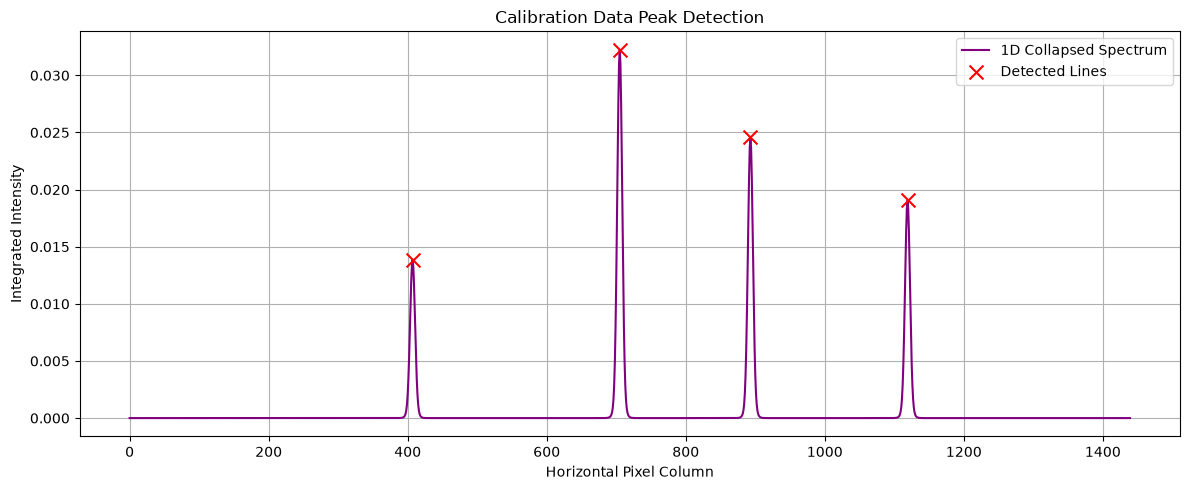

In [137]:
from scipy.ndimage import gaussian_filter1d

# ==========================================
# 6. EXTRACT 1D SIGNAL & FIND PEAKS (FIXED)
# ==========================================
# Step 1: Collapse the 2D image vertically into a 1D spectral array
raw_spectral_profile = np.sum(calib_sensor_image, axis=0)
pixels = np.arange(sensor_width)

# Step 2: Smooth out the Bayer matrix "zigzag" ripples
# A slight Gaussian blur blends the alternating pixel columns into a clean envelope
smoothed_profile = gaussian_filter1d(raw_spectral_profile, sigma=CONFIG.calibration.smoothing_sigma_px)

# Step 3: Locate the sharp pixel peaks with stricter rules
# - distance=100: We know our 4 lines are spread far apart; ignore anything within 100 pixels of a found peak.
# - prominence: The peak must stand out significantly from its local baseline.
peaks, _ = find_peaks(
    smoothed_profile, 
    height=np.max(smoothed_profile) * CONFIG.calibration.peak_height_fraction, 
    distance=CONFIG.calibration.peak_min_distance_px, 
    prominence=np.max(smoothed_profile) * CONFIG.calibration.peak_prominence_fraction
)
detected_pixels = pixels[peaks]

print(f"Found {len(detected_pixels)} calibration peaks at pixel columns: {detected_pixels}")

# Ensure we found all lines before running math
if len(detected_pixels) != len(calib_lines_nm):
    print("Warning: Peak count mismatch! Adjust find_peaks parameters.")

fig, (ax1) = plt.subplots(1, 1, figsize=(12, 5))
# Plot 1: 1D Profile showing peak selection
ax1.plot(pixels, smoothed_profile, color='purple', label='1D Collapsed Spectrum')
ax1.scatter(detected_pixels, smoothed_profile[peaks], color='red', marker='x', s=100, zorder=5, label='Detected Lines')
ax1.set_title("Calibration Data Peak Detection")
ax1.set_xlabel("Horizontal Pixel Column")
ax1.set_ylabel("Integrated Intensity")
ax1.legend()
ax1.grid(True)

plt.tight_layout()
plt.show()


### Polynomial regression

In [138]:
# ==========================================
# 7. POLYNOMIAL REGRESSION (THE CALIBRATION)
# ==========================================
# Compute a mathematically stable 2nd-degree polynomial fit (Pixel -> Wavelength)
calib_function = Polynomial.fit(detected_pixels, calib_lines_nm, deg=CONFIG.calibration.polynomial_degree)

# Generate a continuous wavelength map for every single pixel column on your camera
all_pixels = np.arange(sensor_width)
pixel_to_wavelength_map = calib_function(all_pixels)

# Check our mathematical error (Residuals)
predicted_peaks = calib_function(detected_pixels)
residuals = predicted_peaks - calib_lines_nm
print(f"Calibration Residual Errors (nm): {residuals}")


Calibration Residual Errors (nm): [-0.04505976  0.20033043 -0.22501881  0.06974814]


### Calibration result

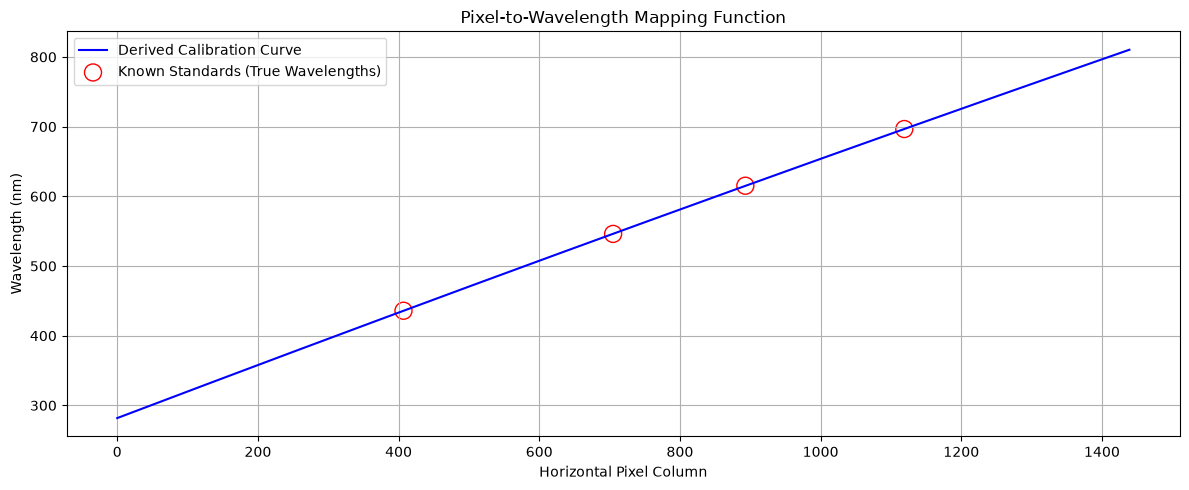


--- Calibration Complete ---
Estimated Spectral Range: 281.82 nm to 810.30 nm
Average Dispersion: 0.3670 nm/pixel


In [139]:
# ==========================================
# 8. PLOT CALIBRATION RESULTS
# ==========================================
# Plot 2: Final Wavelength Mapping Curve
fig, (ax2) = plt.subplots(1, 1, figsize=(12, 5))
ax2.plot(all_pixels, pixel_to_wavelength_map, color='blue', linestyle='-', label='Derived Calibration Curve')
ax2.scatter(detected_pixels, calib_lines_nm, color='red', facecolors='none', edgecolors='red', s=150, label='Known Standards (True Wavelengths)')
ax2.set_title("Pixel-to-Wavelength Mapping Function")
ax2.set_xlabel("Horizontal Pixel Column")
ax2.set_ylabel("Wavelength (nm)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print out your custom system properties derived purely from your image data!
print("\n--- Calibration Complete ---")
print(f"Estimated Spectral Range: {pixel_to_wavelength_map[0]:.2f} nm to {pixel_to_wavelength_map[-1]:.2f} nm")
print(f"Average Dispersion: {(pixel_to_wavelength_map[-1] - pixel_to_wavelength_map[0])/sensor_width:.4f} nm/pixel")

### Testing calibration: RGB LED test


--- Running Unknown Spectrum (RGB LED) Test ---


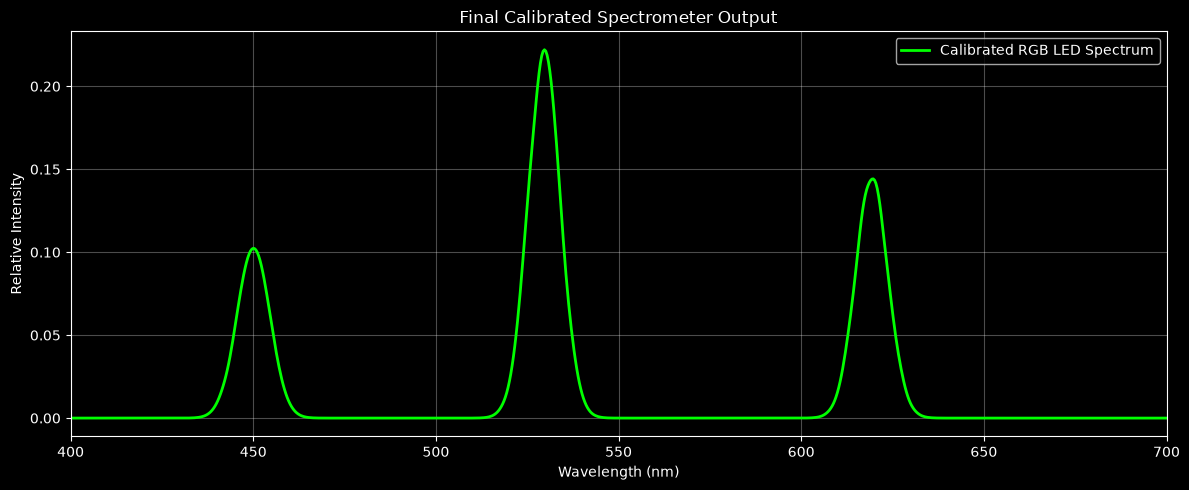

In [140]:
# ==========================================
# 8. TEST CALIBRATION ON "UNKNOWN" SPECTRUM
# ==========================================
print("\n--- Running Unknown Spectrum (RGB LED) Test ---")

# 1. Define our test spectrum (the 300 steps you set up earlier!)
test_wavelengths = wavelengths

# 2. Create a fresh blank sensor matrix for this new measurement
test_sensor_image = np.zeros((sensor_height, sensor_width))

# 3. Run the light through the exact same optical pipeline
for wl in test_wavelengths:
    osys = create_spectrograph_system(wl.to_value(u.nm))
    psf = osys.calc_psf(wavelength=wl)
    mono_image = psf[0].data 
    
    # Grating math
    theta = diffraction_angle(wl) 
    x_position = f_focus * np.tan(theta) 
    absolute_pixel = int(x_position / pixel_size) 
    pixel_shift = int(absolute_pixel - center_pixel_offset + (sensor_width // 2))
    
    h_h, w_h = mono_image.shape
    y_offset = (sensor_height - h_h) // 2
    
    # Center the PSF stamp on pixel_shift, not left-align it
    stamp_left = pixel_shift - w_h // 2
    x0 = max(stamp_left, 0)
    x1 = min(stamp_left + w_h, sensor_width)

    if x1 > x0 and y_offset >= 0:
        src_x0 = x0 - stamp_left
        src_x1 = src_x0 + (x1 - x0)

        wl_nm = wl.to(u.nm).value

        # Use your custom LED function as the "unknown" light source
        source_intensity = rgb_gaussian_source(wl_nm)

        # Apply continuous QE
        qe_b = np.interp(wl_nm, qe_wavelengths, qe_blue_curve)
        qe_g = np.interp(wl_nm, qe_wavelengths, qe_green_curve)
        qe_r = np.interp(wl_nm, qe_wavelengths, qe_red_curve)

        # Apply Bayer Masks
        b_slice = blue_mask[y_offset:y_offset+h_h, x0:x1]
        g_slice = green_mask[y_offset:y_offset+h_h, x0:x1]
        r_slice = red_mask[y_offset:y_offset+h_h, x0:x1]

        combined_response = (qe_b * b_slice) + (qe_g * g_slice) + (qe_r * r_slice)

        # Accumulate photons on the sensor
        test_sensor_image[y_offset:y_offset+h_h, x0:x1] += (
            mono_image[:, src_x0:src_x1] * combined_response * source_intensity
        )

# ==========================================
# 9. EXTRACT & PLOT THE CALIBRATED SPECTRUM
# ==========================================
# Collapse the 2D image vertically
test_spectral_profile = np.sum(test_sensor_image, axis=0)

# Smooth out the Bayer matrix "zigzag" ripples
smoothed_test_profile = gaussian_filter1d(test_spectral_profile, sigma=CONFIG.calibration.smoothing_sigma_px)

all_sensor_pixels = np.arange(sensor_width)
calibrated_wavelengths = calib_function(all_sensor_pixels)

# --- THE MAGIC STEP ---
# Plot using calibrated_wavelengths (from your polynomial) instead of raw pixels!
plt.style.use('dark_background')
plt.figure(figsize=(12, 5))

# X-axis is now scientifically accurate nanometers
plt.plot(calibrated_wavelengths, smoothed_test_profile, color='lime', linewidth=2, label='Calibrated RGB LED Spectrum')

plt.title("Final Calibrated Spectrometer Output")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Relative Intensity")
plt.xlim(400, 700) # Lock the view to our visible range
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.style.use('default')


### Pixel dispersion and resolution check

In [141]:
# Create an array of the exact wavelength for all 1440 pixels
all_wavelengths = calib_function(np.arange(sensor_width))
# np.diff subtracts pixel 0 from pixel 1, pixel 1 from 2, etc.
# This gives the exact nanometer width of every single pixel!
exact_resolution_array = np.diff(all_wavelengths)
# Check the exact resolution at the center of your sensor
center_pixel = sensor_width // 2

# 1. Dispersion (nm/pixel) 
print(f"Dispersion at center pixel: {exact_resolution_array[center_pixel]:.4f} nm/pixel")
print(f"Dispersion at 400nm end:    {exact_resolution_array[100]:.4f} nm/pixel")
print(f"Dispersion at 700nm end:    {exact_resolution_array[-100]:.4f} nm/pixel")
# Note: dispersion increases toward red end 

# 2. Estimate PSF width in pixels from your calibration image
calib_1d = calib_sensor_image.sum(axis=0)
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

def gaussian(x, center, sigma, amplitude, offset):
    return amplitude * np.exp(-0.5*((x - center)/sigma)**2) + offset

peaks, _ = find_peaks(calib_1d, height=calib_1d.max()*0.05, distance=20)

print(f"\nPSF width (FWHM) per calibration line:")
fwhm_list = []
for p in peaks:
    window = np.arange(max(0, p-30), min(sensor_width, p+30))
    chunk = calib_1d[window]
    try:
        popt, _ = curve_fit(gaussian, window, chunk,
                            p0=[p, 5, chunk.max(), chunk.min()])
        sigma = abs(popt[1])
        fwhm_px = 2.355 * sigma          # FWHM = 2.355 * sigma for a Gaussian
        fwhm_nm = fwhm_px * exact_resolution_array[int(popt[0])]
        fwhm_list.append((p, fwhm_px, fwhm_nm))
        wl_at_peak = all_wavelengths[int(popt[0])]
        print(f"  {wl_at_peak:.1f}nm -> FWHM = {fwhm_px:.2f}px = {fwhm_nm:.3f}nm")
    except:
        print(f"  peak at pixel {p}: Gaussian fit failed")

# 3. True resolving power R = λ / Δλ
print(f"\nTrue resolving power R = λ/Δλ:")
for p, fwhm_px, fwhm_nm in fwhm_list:
    wl = all_wavelengths[p]
    R = wl / fwhm_nm
    print(f"  {wl:.1f}nm -> R = {R:.0f}")

Dispersion at center pixel: 0.3672 nm/pixel
Dispersion at 400nm end:    0.3805 nm/pixel
Dispersion at 700nm end:    0.3540 nm/pixel

PSF width (FWHM) per calibration line:
  435.8nm -> FWHM = 4.63px = 1.730nm
  546.3nm -> FWHM = 4.64px = 1.706nm
  615.0nm -> FWHM = 4.65px = 1.692nm
  696.3nm -> FWHM = 4.65px = 1.669nm

True resolving power R = λ/Δλ:
  435.8nm -> R = 252
  546.3nm -> R = 320
  614.6nm -> R = 363
  696.3nm -> R = 417


#### Testing on H-alpha & [NII] emission lines

In [142]:
# # ==========================================
# # 10. NEBULA EMISSION TEST: H-ALPHA & [NII]
# # ==========================================
# print("\n--- Running Nebula Emission Test ---")

# # Reset our blank camera canvas
# sensor_height = 1080
# sensor_width = 1440
# pixel_size = 3.45 * u.micron
# final_spectrum_image = np.zeros((sensor_height, sensor_width)) 

# d_spacing = 1666.67 * u.nm 
# f_focus = 20 * u.mm

# # Anchor H-alpha so it lands exactly in the middle of the sensor (Pixel 720)
# ha_theta = np.arcsin(656.28 * u.nm / d_spacing)
# ha_x = f_focus * np.tan(ha_theta)
# ha_pixel_center = int(ha_x / pixel_size)

# emission_lines = [
#     {"wavelength": 656.28 * u.nm, "intensity": 1.0, "name": "H-alpha"},
#     {"wavelength": 658.40 * u.nm, "intensity": 0.5, "name": "[NII]"}
# ]

# for line in emission_lines:
#     wl = line["wavelength"]
#     brightness = line["intensity"]
    
#     psf = osys.calc_psf(wavelength=wl)
#     mono_image = psf[0].data 
    
#     # Grating math
#     theta = np.arcsin(wl / d_spacing)
#     x_position = f_focus * np.tan(theta)
#     absolute_pixel = int(x_position / pixel_size)
    
#     # Center relative to the H-alpha anchor
#     pixel_shift = absolute_pixel - ha_pixel_center + (sensor_width // 2)
    
#     h_h, w_h = mono_image.shape
#     y_offset = (sensor_height - h_h) // 2
    
#     # --- ROBUST CLIPPING LOGIC ---
#     x0 = max(pixel_shift, 0)
#     x1 = min(pixel_shift + w_h, sensor_width)
    
#     if x1 > x0 and y_offset >= 0:
#         src_x0 = x0 - pixel_shift
#         src_x1 = src_x0 + (x1 - x0)

#         wl_nm = wl.to(u.nm).value 
        
#         # Continuous QE logic (assumes qe_wavelengths, etc. are in memory from earlier)
#         qe_b = np.interp(wl_nm, qe_wavelengths, qe_blue_curve)
#         qe_g = np.interp(wl_nm, qe_wavelengths, qe_green_curve)
#         qe_r = np.interp(wl_nm, qe_wavelengths, qe_red_curve)
        
#         # Slice out the matching Bayer masks
#         b_slice = blue_mask[y_offset:y_offset+h_h, x0:x1]
#         g_slice = green_mask[y_offset:y_offset+h_h, x0:x1]
#         r_slice = red_mask[y_offset:y_offset+h_h, x0:x1]
        
#         combined_response = (qe_b * b_slice) + (qe_g * g_slice) + (qe_r * r_slice)
        
#         # Apply brightness, combined mask response, and accumulate safely
#         final_spectrum_image[y_offset:y_offset+h_h, x0:x1] += (
#             mono_image[:, src_x0:src_x1] * combined_response * brightness
#         )

# # Display the 2D spectrum
# plt.figure(figsize=(11, 8))
# # Using 'magma' or 'inferno' nicely highlights the red intensity!
# plt.imshow(final_spectrum_image, cmap='inferno', extent=[0, sensor_width, sensor_height, 0]) 
# plt.title("Centered Nebula Spectrum: H-alpha & [NII] (1440x1080)")
# plt.xlabel("Spectral Axis (Column Pixel)")
# plt.ylabel("Spatial Position along Telescope Slit (Row Pixel)")
# plt.colorbar(label='Relative Photon Count')
# plt.show()

# # Optional: Plot the 1D profile to easily see the peak separation
# plt.figure(figsize=(11, 4))
# plt.plot(np.sum(final_spectrum_image, axis=0), color='red')
# plt.title("1D Profile: H-alpha and [NII] Separation")
# plt.xlabel("Pixel Column")
# plt.ylabel("Intensity")
# plt.grid(alpha=0.3)
# plt.xlim((sensor_width//2) - 50, (sensor_width//2) + 50) # Zoom in on the center
# plt.show()

